In [48]:
# PRICE HELPER — run this before the optimizer cells
# Self-contained so it works regardless of the order of later helper functions.

def get_product_price(product):
    """Return a positive product price as float, or None if unavailable."""

    if product is None:
        return None

    # Normalized retrieval DataFrame rows expose price_inr directly.
    try:
        price = product.get("price_inr")
    except AttributeError:
        price = None

    # Raw JSON dictionaries may store the value under pricing.price_inr.
    if price is None:
        try:
            pricing = product.get("pricing")
        except AttributeError:
            pricing = None

        if isinstance(pricing, dict):
            price = pricing.get("price_inr")

    # Treat NaN / blank / invalid values as unavailable.
    if price is None:
        return None

    try:
        value = float(price)
    except (TypeError, ValueError):
        return None

    if value != value:  # NaN check
        return None

    return value if value > 0 else None


print("get_product_price() is ready.")


get_product_price() is ready.


# KOHLER AI Bathroom Designer — Retrieval + Constraint-Aware Bundle Optimizer

This notebook keeps the working **retrieval + ChromaDB pipeline** and replaces the old bundle logic with an updated **constraint-aware bundle optimizer**.

### Pipeline

```text
Product JSON
    ↓
Structured cleaning + normalization
    ↓
ChromaDB semantic retrieval
    ↓
Theme-aware candidate selection
    ↓
Bundle generation
    ↓
Budget validation
    ↓
Physical-space validation + deterministic placement
    ↓
Compatibility validation
    ↓
Theme + feature scoring
    ↓
Final bundle ranking
    ↓
Best Match / Budget Optimized / Premium
```

### Prototype assumptions

- Prices come from the updated prototype JSON and are marked as estimates.
- Missing source dimensions were completed using prototype estimates.
- The output is therefore suitable for the case-study prototype, not purchasing-grade data.
- The optimizer never invents prices, dimensions, collisions, or compatibility facts.
- Compatibility is `UNKNOWN` when the catalog does not contain enough explicit information to prove it.


In [49]:
# Cell 2 — Imports

import json
import math
from pathlib import Path

import chromadb
import pandas as pd

print("ChromaDB version:", chromadb.__version__)
print("Pandas version:", pd.__version__)
print("Imports successful.")


ChromaDB version: 1.5.9
Pandas version: 3.0.5
Imports successful.


In [50]:
# Cell 3 — Configuration

JSON_PATH = Path(
    r"C:\Users\Abhist\Desktop\KOHLER\DATA\kohler_ai_bathroom.products_prototype_budget_dimensions.json"
)

CHROMA_PATH = Path(
    r"C:\Users\Abhist\Desktop\KOHLER\data\chroma_db"
)

COLLECTION_NAME = "kohler_products"

print("JSON path:", JSON_PATH)
print("JSON exists:", JSON_PATH.exists())
print("Chroma path:", CHROMA_PATH)


JSON path: C:\Users\Abhist\Desktop\KOHLER\DATA\kohler_ai_bathroom.products_prototype_budget_dimensions.json
JSON exists: True
Chroma path: C:\Users\Abhist\Desktop\KOHLER\data\chroma_db


In [51]:
# Cell 4 — Load product JSON

if not JSON_PATH.exists():
    raise FileNotFoundError(
        f"Product JSON was not found at:\n{JSON_PATH}\n\n"
        "Check the JSON_PATH in Cell 3."
    )

with open(JSON_PATH, "r", encoding="utf-8") as f:
    products = json.load(f)

if not isinstance(products, list):
    raise ValueError(
        "Expected the JSON root to contain a list of products."
    )

print("Products loaded:", len(products))
print("Data type:", type(products).__name__)

if len(products) == 0:
    raise ValueError("The product JSON contains no products.")


Products loaded: 36
Data type: list


In [52]:
# Cell 5 — Inspect one product

print(json.dumps(products[0], indent=4, ensure_ascii=False))


{
    "_id": {
        "$oid": "6aa96a2826ad3942f37da9fc"
    },
    "product_id": "1408991-IN4-A",
    "category": "Other",
    "collection": "Not specified",
    "color": [
        "White"
    ],
    "dimensions": {
        "width_mm": 344,
        "depth_mm": 483,
        "height_mm": 141,
        "width_mm_available": true,
        "depth_mm_available": true,
        "height_mm_available": true,
        "dimension_source": {
            "width_mm": "source",
            "depth_mm": "source",
            "height_mm": "source"
        },
        "all_dimensions_available": true
    },
    "electrical": {
        "required": false,
        "required_source": "source",
        "voltage": "Not specified",
        "power_w": -1,
        "power_available": false
    },
    "extraction_method": "Groq text extraction",
    "extraction_status": "success",
    "features": [
        "Ergonomic and Straight line design suitable for compact rooms with deck space.",
        "Easy installation as 

In [53]:
# Cell 6 — Flatten product data

df = pd.json_normalize(products)

print("Number of products:", len(df))
print("Number of fields:", len(df.columns))

display(df.head())


Number of products: 36
Number of fields: 45


,product_id,category,collection,color,extraction_method,extraction_status,features,material,product_name,source_pdf,...,electrical.power_w,electrical.power_available,installation.type,installation.waste_outlet,installation.rough_in_mm,installation.rough_in_available,pricing.price_inr,pricing.currency,pricing.price_source,pricing.price_estimated
0,1408991-IN4-A,Other,Not specified,[White],Groq text extraction,success,[Ergonomic and Straight line design suitable f...,Vitreous China,SPAN® Square Vessel Without Deck ( Small),1408991-IN4.pdf,...,-1,False,Above Counter,Not specified,-1,False,18000,INR,prototype_estimate,True
1,29024IN-1,Vessel,Not specified,[White],Groq text extraction,success,"[Vitreous China, Circular Design, Without Over...",Vitreous China,CHALICE ROUND VESSEL 1TAP HOLE,29024IN-1_Chalice w deck vessel.pdf,...,-1,False,Above counter,Not specified,-1,False,18000,INR,prototype_estimate,True
2,1311520-A04-D,BASINS / COUNTERTOP,Not specified,"[white, honed black]",Groq text extraction,success,"[Bench top installation, Slim vessel, CleanCoa...",Ceramic,Mica® Square 393mm Basin,90011T.pdf,...,-1,False,Bench top installation,DN32 waste without overflow,50,True,18000,INR,prototype_estimate,True
3,K-12927IN,Other,Not specified,"[Polished Chrome, Vibrant® French Gold, Vibran...",Groq text extraction,success,[Designed to coordinate with a range of KOHLER...,Not specified,Complimentary™ Hygiene Spray,K-12927IN_spec_IN_Kohler_en.pdf,...,-1,False,Wall-mount,Not specified,-1,False,6500,INR,prototype_estimate,True
4,K-1381T-S,Toilet,Veil,[White],Groq text extraction,success,[One-piece toilets integrate the tank and bowl...,Plastic seat,Veil™ One-piece elongated toilet with skirted ...,K-1381T-S_spec_IN_Kohler_en.pdf,...,-1,False,Floor-mount,Floor,305,True,48000,INR,prototype_estimate,True


In [54]:
# Cell 7 — Create retrieval dataset

retrieval_df = df.copy()

# Make sure important columns exist.
required_columns = [
    "product_id",
    "product_name",
    "category",
    "subcategory",
    "collection",
    "material",
    "color",
    "features",
    "price_inr",
    "price_estimated",
    "pricing.price_inr",
    "pricing.currency",
    "pricing.price_source",
    "pricing.price_estimated",
    "all_dimensions_available",
    "dimension_source.width_mm",
    "dimension_source.depth_mm",
    "dimension_source.height_mm",
]

for column in required_columns:
    if column not in retrieval_df.columns:
        retrieval_df[column] = pd.NA

print("Retrieval dataset created.")
print("Products:", len(retrieval_df))


Retrieval dataset created.
Products: 36


In [55]:
# Cell 8 — Normalize categories

def normalize_category(category):
    """Convert inconsistent source categories into stable retrieval categories."""

    if category is None:
        return "Other"

    # Avoid treating pandas missing values as booleans.
    try:
        if pd.isna(category):
            return "Other"
    except (TypeError, ValueError):
        pass

    value = str(category).strip().lower()

    if not value or value in {"none", "nan", "not specified"}:
        return "Other"

    # Check specific categories before broader categories.
    if "toilet seat" in value:
        return "Toilet Seat"

    if "toilet" in value:
        return "Toilet"

    if "faucet trim" in value:
        return "Faucet Trim"

    if "faucet" in value:
        return "Faucet"

    if "shower" in value:
        return "Shower"

    if "vanity" in value:
        return "Vanity"

    if "bathtub" in value or "bath tub" in value:
        return "Bathtub"

    if "mirror" in value or "cabinet" in value:
        return "Mirror"

    if "sink" in value or "basin" in value or "vessel" in value:
        return "Sink"

    return "Other"


retrieval_df["category_normalized"] = (
    retrieval_df["category"].apply(normalize_category)
)

print("Normalized categories:")
display(retrieval_df["category_normalized"].value_counts())


Normalized categories:


category_normalized
Faucet         15
Sink           10
Toilet          5
Other           4
Toilet Seat     1
Faucet Trim     1
Name: count, dtype: int64

In [56]:
# Cell 9 — Clean numeric fields

numeric_fields = [
    "dimensions.width_mm",
    "dimensions.depth_mm",
    "dimensions.height_mm",
    "dimensions.width_mm_available",
    "dimensions.depth_mm_available",
    "dimensions.height_mm_available",
    "electrical.power_w",
    "installation.rough_in_mm",
    "installation.rough_in_available",
]

for field in numeric_fields:
    if field in retrieval_df.columns:
        retrieval_df[field] = pd.to_numeric(
            retrieval_df[field],
            errors="coerce"
        )

# Negative measurements/power values are invalid for retrieval.
non_negative_fields = [
    "dimensions.width_mm",
    "dimensions.depth_mm",
    "dimensions.height_mm",
    "electrical.power_w",
    "installation.rough_in_mm",
]

for field in non_negative_fields:
    if field in retrieval_df.columns:
        retrieval_df.loc[
            retrieval_df[field] < 0,
            field
        ] = pd.NA

print("Numeric fields cleaned.")


Numeric fields cleaned.


In [57]:
# Cell 10 — Prepare price field

# The updated prototype JSON stores price inside:
# pricing.price_inr
#
# We expose it as the simple column price_inr so the rest of the
# retrieval and bundle optimizer can use it consistently.

if "pricing.price_inr" in retrieval_df.columns:
    retrieval_df["price_inr"] = pd.to_numeric(
        retrieval_df["pricing.price_inr"],
        errors="coerce"
    )
elif "price_inr" in retrieval_df.columns:
    retrieval_df["price_inr"] = pd.to_numeric(
        retrieval_df["price_inr"],
        errors="coerce"
    )
elif "price" in retrieval_df.columns:
    retrieval_df["price_inr"] = pd.to_numeric(
        retrieval_df["price"],
        errors="coerce"
    )
else:
    retrieval_df["price_inr"] = pd.NA

# Carry the prototype-estimate flag.
if "pricing.price_estimated" in retrieval_df.columns:
    retrieval_df["price_estimated"] = (
        retrieval_df["pricing.price_estimated"]
        .fillna(False)
        .astype(bool)
    )
elif "price_estimated" not in retrieval_df.columns:
    retrieval_df["price_estimated"] = False

print("Products with known price:", retrieval_df["price_inr"].notna().sum())
print("Products without price:", retrieval_df["price_inr"].isna().sum())

if retrieval_df["price_inr"].notna().sum() > 0:
    print(
        "Prototype price range (INR):",
        int(retrieval_df["price_inr"].min()),
        "to",
        int(retrieval_df["price_inr"].max())
    )

# Verify the updated JSON has complete usable dimensions.
dimension_fields = [
    "dimensions.width_mm",
    "dimensions.depth_mm",
    "dimensions.height_mm",
]

for field in dimension_fields:
    retrieval_df[field] = pd.to_numeric(
        retrieval_df[field],
        errors="coerce"
    )

dimension_complete_mask = retrieval_df[dimension_fields].notna().all(axis=1)

print(
    "Products with complete numeric dimensions:",
    int(dimension_complete_mask.sum()),
    "/",
    len(retrieval_df)
)

if not dimension_complete_mask.all():
    print("WARNING: Some products still have missing dimensions.")
    display(
        retrieval_df.loc[
            ~dimension_complete_mask,
            ["product_id", "product_name"] + dimension_fields
        ]
    )


Products with known price: 36
Products without price: 0
Prototype price range (INR): 4500 to 145000
Products with complete numeric dimensions: 36 / 36


In [58]:
# Cell 11 — Safe value helpers

def is_missing(value):
    """Safely determine whether a scalar value is missing."""
    if value is None:
        return True

    try:
        result = pd.isna(value)
        return bool(result) if not hasattr(result, "__len__") else False
    except (TypeError, ValueError):
        return False


def clean_text(value):
    """Convert a scalar value to clean text or None."""
    if is_missing(value):
        return None

    value = str(value).strip()

    if not value or value.lower() in {"nan", "none", "not specified"}:
        return None

    return value


def clean_list(value):
    """Convert list/string values into a clean list of strings."""
    if is_missing(value):
        return []

    if isinstance(value, list):
        result = []
        for item in value:
            item = clean_text(item)
            if item and item not in result:
                result.append(item)
        return result

    item = clean_text(value)
    return [item] if item else []


print("Helper functions ready.")


Helper functions ready.


In [59]:
# Cell 12 — Structured constraint helpers

def apply_max_constraint(dataframe, field, maximum):
    """
    Keep:
      - known value <= maximum
      - missing value

    Reject:
      - known value > maximum

    Missing values remain candidates because they need later validation
    rather than being silently treated as a failure.
    """
    if maximum is None or field not in dataframe.columns:
        return dataframe

    values = pd.to_numeric(dataframe[field], errors="coerce")

    mask = values.isna() | (values <= float(maximum))

    return dataframe[mask]


def apply_budget_constraint(dataframe, max_price_inr=None):
    """Apply a maximum price constraint while preserving unknown prices."""
    if max_price_inr is None or "price_inr" not in dataframe.columns:
        return dataframe

    prices = pd.to_numeric(
        dataframe["price_inr"],
        errors="coerce"
    )

    mask = prices.isna() | (prices <= float(max_price_inr))

    return dataframe[mask]


def apply_installation_constraint(dataframe, installation_type=None):
    """Apply installation type while retaining unknown installation data."""
    if installation_type is None:
        return dataframe

    field = "installation.type"

    if field not in dataframe.columns:
        return dataframe

    requested = str(installation_type).strip().lower()

    values = (
        dataframe[field]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    unknown = values.isin({"", "none", "nan", "not specified"})

    return dataframe[
        values.eq(requested) | unknown
    ]


def apply_rough_in_constraint(dataframe, required_rough_in_mm=None, tolerance_mm=10):
    """Apply rough-in compatibility with a configurable tolerance."""
    if required_rough_in_mm is None:
        return dataframe

    field = "installation.rough_in_mm"

    if field not in dataframe.columns:
        return dataframe

    values = pd.to_numeric(
        dataframe[field],
        errors="coerce"
    )

    compatible = (
        values.sub(float(required_rough_in_mm)).abs()
        <= float(tolerance_mm)
    )

    return dataframe[
        values.isna() | compatible
    ]


def apply_electrical_constraint(dataframe, electrical_required=None):
    """Apply electrical requirement while preserving unknown values."""
    if electrical_required is None:
        return dataframe

    field = "electrical.required"

    if field not in dataframe.columns:
        return dataframe

    values = dataframe[field].astype("object")

    normalized = (
        values
        .astype(str)
        .str.strip()
        .str.lower()
    )

    true_values = normalized.isin({"true", "yes", "1"})
    false_values = normalized.isin({"false", "no", "0"})
    unknown = ~(true_values | false_values)

    if bool(electrical_required):
        mask = true_values | unknown
    else:
        mask = false_values | unknown

    return dataframe[mask]


In [60]:
# Cell 13 — Main structured retrieval function

def filter_products(
    dataframe,
    category=None,
    max_price_inr=None,
    max_width_mm=None,
    max_depth_mm=None,
    max_height_mm=None,
    installation_type=None,
    required_rough_in_mm=None,
    electrical_required=None,
):
    """
    Retrieve products using exact structured constraints.

    Hard constraints:
      category
      budget
      width
      depth
      height
      installation type
      rough-in
      electrical requirement

    Missing source values are retained as candidates and are handled
    later by validation.
    """

    result = dataframe.copy()

    if category is not None:
        requested = str(category).strip().lower()

        if "category_normalized" in result.columns:
            categories = (
                result["category_normalized"]
                .fillna("Other")
                .astype(str)
                .str.strip()
                .str.lower()
            )

            result = result[categories.eq(requested)]

    result = apply_budget_constraint(
        result,
        max_price_inr
    )

    result = apply_max_constraint(
        result,
        "dimensions.width_mm",
        max_width_mm
    )

    result = apply_max_constraint(
        result,
        "dimensions.depth_mm",
        max_depth_mm
    )

    result = apply_max_constraint(
        result,
        "dimensions.height_mm",
        max_height_mm
    )

    result = apply_installation_constraint(
        result,
        installation_type
    )

    result = apply_rough_in_constraint(
        result,
        required_rough_in_mm
    )

    result = apply_electrical_constraint(
        result,
        electrical_required
    )

    return result.reset_index(drop=True)


print("Structured retrieval function ready.")


Structured retrieval function ready.


In [61]:
# Cell 14 — Test structured retrieval

structured_results = filter_products(
    retrieval_df,
    category="Toilet",
    max_depth_mm=700,
    max_height_mm=500,
    installation_type="Floor-mount",
    required_rough_in_mm=305,
)

print("Structured candidates:", len(structured_results))

display(
    structured_results[
        [
            "product_id",
            "product_name",
            "category_normalized",
            "price_inr",
            "dimensions.width_mm",
            "dimensions.depth_mm",
            "dimensions.height_mm",
        ]
    ]
)


Structured candidates: 3


,product_id,product_name,category_normalized,price_inr,dimensions.width_mm,dimensions.depth_mm,dimensions.height_mm
0,K-1381T-S,Veil™ One-piece elongated toilet with skirted ...,Toilet,48000,380.0,650.0,390.0
1,K-28529IN,"Leap™ One-piece round-front smart toilet, dual...",Toilet,145000,370.0,650.0,400.0
2,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,Toilet,42000,370.0,650.0,391.0


In [62]:
# Cell 15 — Product validation

def check_max_value(value, maximum):
    if maximum is None:
        return True
    if is_missing(value):
        return None
    return float(value) <= float(maximum)


def check_rough_in(value, required, tolerance_mm=10):
    if required is None:
        return True
    if is_missing(value):
        return None
    return abs(float(value) - float(required)) <= tolerance_mm


def validate_product(
    product,
    max_price_inr=None,
    max_width_mm=None,
    max_depth_mm=None,
    max_height_mm=None,
    required_rough_in_mm=None,
    installation_type=None,
    electrical_required=None,
):
    """Return PASS / FAIL / UNKNOWN-compatible boolean checks."""

    checks = {}

    # Budget
    if max_price_inr is not None:
        price = product.get("price_inr")

        if is_missing(price):
            checks["budget"] = None
        else:
            checks["budget"] = float(price) <= float(max_price_inr)

    # Dimensions
    checks["width"] = check_max_value(
        product.get("dimensions.width_mm"),
        max_width_mm
    )

    checks["depth"] = check_max_value(
        product.get("dimensions.depth_mm"),
        max_depth_mm
    )

    checks["height"] = check_max_value(
        product.get("dimensions.height_mm"),
        max_height_mm
    )

    # Rough-in
    checks["rough_in"] = check_rough_in(
        product.get("installation.rough_in_mm"),
        required_rough_in_mm
    )

    # Installation
    if installation_type is not None:
        actual = clean_text(
            product.get("installation.type")
        )

        if actual is None:
            checks["installation"] = None
        else:
            checks["installation"] = (
                actual.strip().lower()
                == str(installation_type).strip().lower()
            )

    # Electrical
    if electrical_required is not None:
        value = product.get("electrical.required")

        if is_missing(value):
            checks["electrical"] = None
        else:
            normalized = str(value).strip().lower()

            if normalized in {"true", "yes", "1"}:
                actual = True
            elif normalized in {"false", "no", "0"}:
                actual = False
            else:
                actual = None

            checks["electrical"] = (
                None
                if actual is None
                else actual == bool(electrical_required)
            )

    return checks


def summarize_checks(checks):
    result = {}

    for constraint, value in checks.items():
        if value is True:
            result[constraint] = "PASS"
        elif value is False:
            result[constraint] = "FAIL"
        else:
            result[constraint] = "UNKNOWN"

    return result


In [63]:
# Cell 16 — Create validation report

def create_validation_report(dataframe, **requirements):
    reports = []

    for _, product in dataframe.iterrows():
        checks = validate_product(
            product,
            **requirements
        )

        summary = summarize_checks(checks)

        report = {
            "product_id": product.get("product_id"),
            "product_name": product.get("product_name"),
            "category": product.get("category_normalized"),
        }

        for constraint, status in summary.items():
            report[f"{constraint}_status"] = status

        reports.append(report)

    return pd.DataFrame(reports)


validation_report = create_validation_report(
    retrieval_df,
    max_depth_mm=700,
    max_height_mm=500,
    required_rough_in_mm=305,
    installation_type="Floor-mount",
)

display(validation_report.head(10))


,product_id,product_name,category,width_status,depth_status,height_status,rough_in_status,installation_status
0,1408991-IN4-A,SPAN® Square Vessel Without Deck ( Small),Other,PASS,PASS,PASS,UNKNOWN,FAIL
1,29024IN-1,CHALICE ROUND VESSEL 1TAP HOLE,Sink,PASS,PASS,PASS,UNKNOWN,FAIL
2,1311520-A04-D,Mica® Square 393mm Basin,Sink,PASS,PASS,PASS,FAIL,FAIL
3,K-12927IN,Complimentary™ Hygiene Spray,Other,PASS,PASS,PASS,UNKNOWN,FAIL
4,K-1381T-S,Veil™ One-piece elongated toilet with skirted ...,Toilet,PASS,PASS,PASS,PASS,PASS
5,K-17629T-NS,Ove™ One-piece round-front toilet with skirted...,Toilet,PASS,PASS,PASS,FAIL,PASS
6,K-17660T-M,Ove™ Quiet-Close™ elongated toilet seat,Toilet Seat,PASS,PASS,PASS,UNKNOWN,UNKNOWN
7,K-1851IN,Brive Plus,Other,PASS,PASS,PASS,FAIL,PASS
8,K-1853IN,Brive Plus,Other,PASS,PASS,PASS,FAIL,PASS
9,K-21226IN,ModernLife Edge 600 mm rectangular vessel bath...,Sink,PASS,PASS,PASS,UNKNOWN,FAIL


## Semantic Retrieval with ChromaDB

The semantic layer uses product descriptions rather than hard constraints.

Examples of semantic concepts:

- Japanese Zen
- minimalist
- modern
- luxury
- elegant
- clean lines
- calm aesthetic
- water-efficient
- smart bathroom

Dimensions, budget, and other hard constraints are **not trusted to semantic similarity**.


In [64]:
# Cell 17 — Build semantic text

def create_semantic_text(product):
    """Create a robust natural-language representation for embeddings."""

    parts = []

    product_name = clean_text(product.get("product_name"))
    category = clean_text(product.get("category_normalized"))
    subcategory = clean_text(product.get("subcategory"))
    collection = clean_text(product.get("collection"))
    material = clean_text(product.get("material"))
    installation = clean_text(product.get("installation.type"))

    if product_name:
        parts.append(f"Product: {product_name}")

    if category:
        parts.append(f"Category: {category}")

    if subcategory:
        parts.append(f"Subcategory: {subcategory}")

    if collection:
        parts.append(f"Collection: {collection}")

    if material:
        parts.append(f"Material: {material}")

    colors = clean_list(product.get("color"))
    if colors:
        parts.append("Color: " + ", ".join(colors))

    features = clean_list(product.get("features"))
    if features:
        parts.append("Features: " + ", ".join(features))

    if installation:
        parts.append(f"Installation: {installation}")

    # Include dimensions and price in the document so retrieved products
    # retain useful prototype context.
    width = product.get("dimensions.width_mm")
    depth = product.get("dimensions.depth_mm")
    height = product.get("dimensions.height_mm")

    if not any(is_missing(x) for x in [width, depth, height]):
        parts.append(
            f"Dimensions: {float(width):.0f} x {float(depth):.0f} x {float(height):.0f} mm"
        )

    price = product.get("price_inr")
    if not is_missing(price):
        parts.append(f"Prototype price: INR {float(price):.0f}")

    # Include useful electrical information when explicitly known.
    electrical_required = product.get("electrical.required")
    if not is_missing(electrical_required):
        parts.append(
            f"Electrical required: {str(electrical_required)}"
        )

    return ". ".join(parts)


retrieval_df["semantic_text"] = retrieval_df.apply(
    create_semantic_text,
    axis=1
)

# Guarantee that Chroma never receives an empty document.
retrieval_df["semantic_text"] = retrieval_df["semantic_text"].apply(
    lambda x: x if clean_text(x) else "KOHLER bathroom product."
)

print("Semantic text created.")
display(
    retrieval_df[
        [
            "product_id",
            "product_name",
            "category_normalized",
            "price_inr",
            "semantic_text",
        ]
    ].head(5)
)


Semantic text created.


,product_id,product_name,category_normalized,price_inr,semantic_text
0,1408991-IN4-A,SPAN® Square Vessel Without Deck ( Small),Other,18000,Product: SPAN® Square Vessel Without Deck ( Sm...
1,29024IN-1,CHALICE ROUND VESSEL 1TAP HOLE,Sink,18000,Product: CHALICE ROUND VESSEL 1TAP HOLE. Categ...
2,1311520-A04-D,Mica® Square 393mm Basin,Sink,18000,Product: Mica® Square 393mm Basin. Category: S...
3,K-12927IN,Complimentary™ Hygiene Spray,Other,6500,Product: Complimentary™ Hygiene Spray. Categor...
4,K-1381T-S,Veil™ One-piece elongated toilet with skirted ...,Toilet,48000,Product: Veil™ One-piece elongated toilet with...


In [65]:
# Cell 18 — Initialize ChromaDB

CHROMA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

chroma_client = chromadb.PersistentClient(
    path=str(CHROMA_PATH)
)

print("ChromaDB initialized.")
print("Database path:", CHROMA_PATH)


ChromaDB initialized.
Database path: C:\Users\Abhist\Desktop\KOHLER\data\chroma_db


In [66]:
# Cell 19 — Initialize embedding function

from chromadb.utils.embedding_functions import DefaultEmbeddingFunction

embedding_function = DefaultEmbeddingFunction()

print("Default embedding function initialized.")


Default embedding function initialized.


In [67]:
# Cell 20 — Test embeddings

test_text = [
    "Japanese Zen minimalist bathroom faucet"
]

test_embedding = embedding_function(test_text)

print("Embedding generated successfully.")
print("Number of embeddings:", len(test_embedding))

if len(test_embedding) > 0:
    print("Embedding dimension:", len(test_embedding[0]))


Embedding generated successfully.
Number of embeddings: 1
Embedding dimension: 384


In [68]:
# Cell 21 — Create a fresh Chroma collection

# IMPORTANT:
# The product JSON has changed. Reusing an old collection can leave
# stale embeddings/metadata. For the prototype, rebuild the collection
# every time this notebook is run.

try:
    chroma_client.delete_collection(name=COLLECTION_NAME)
    print(f"Deleted existing collection: {COLLECTION_NAME}")
except Exception:
    print("No existing collection to delete.")

collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    metadata={"description": "KOHLER prototype bathroom product catalog"}
)

print("Fresh Chroma collection created:", COLLECTION_NAME)


Deleted existing collection: kohler_products
Fresh Chroma collection created: kohler_products


In [69]:
# Cell 22 — Prepare Chroma metadata

def chroma_metadata_value(value):
    """Convert a value to a Chroma-safe scalar."""

    if is_missing(value):
        return "Not specified"

    if isinstance(value, list):
        cleaned = clean_list(value)
        return ", ".join(cleaned) if cleaned else "Not specified"

    return value


chroma_ids = []
chroma_documents = []
chroma_metadatas = []

for _, product in retrieval_df.iterrows():

    product_id = clean_text(product.get("product_id"))

    if not product_id:
        continue

    chroma_ids.append(product_id)
    chroma_documents.append(product["semantic_text"])

    chroma_metadatas.append({
        "product_id": product_id,
        "product_name": chroma_metadata_value(product.get("product_name")),
        "category": chroma_metadata_value(product.get("category_normalized")),
        "collection": chroma_metadata_value(product.get("collection")),
        "material": chroma_metadata_value(product.get("material")),
        "color": chroma_metadata_value(product.get("color")),
        "installation_type": chroma_metadata_value(product.get("installation.type")),
        "price_inr": float(product["price_inr"]) if not is_missing(product.get("price_inr")) else -1.0,
        "price_estimated": bool(product.get("price_estimated", False)),
        "width_mm": float(product["dimensions.width_mm"]) if not is_missing(product.get("dimensions.width_mm")) else -1.0,
        "depth_mm": float(product["dimensions.depth_mm"]) if not is_missing(product.get("dimensions.depth_mm")) else -1.0,
        "height_mm": float(product["dimensions.height_mm"]) if not is_missing(product.get("dimensions.height_mm")) else -1.0,
    })


print("Chroma records prepared.")
print("IDs:", len(chroma_ids))
print("Documents:", len(chroma_documents))
print("Metadata:", len(chroma_metadatas))


Chroma records prepared.
IDs: 36
Documents: 36
Metadata: 36


In [70]:
# Cell 23 — Upsert products into ChromaDB

if not chroma_ids:
    raise ValueError("No valid product IDs were available for ChromaDB.")

collection.upsert(
    ids=chroma_ids,
    documents=chroma_documents,
    metadatas=chroma_metadatas,
)

print("Products upserted successfully.")
print("ChromaDB record count:", collection.count())


Products upserted successfully.
ChromaDB record count: 36


In [71]:
# Cell 24 — Basic semantic retrieval

def semantic_search(
    query,
    n_results=5,
    category=None,
):
    """
    Search products semantically.

    Optional category is applied as a Chroma metadata filter.
    """

    query = clean_text(query)

    if not query:
        raise ValueError("Semantic query cannot be empty.")

    n_results = max(1, int(n_results))

    kwargs = {
        "query_texts": [query],
        "n_results": n_results,
    }

    if category is not None:
        kwargs["where"] = {
            "category": str(category)
        }

    return collection.query(**kwargs)


semantic_results = semantic_search(
    "Japanese Zen minimalist calm elegant bathroom fixture",
    n_results=5,
)

print("Semantic results:")
for rank, product_id in enumerate(
    semantic_results["ids"][0],
    start=1
):
    print(f"{rank}. {product_id}")


Semantic results:
1. K-1851IN
2. K-1381T-S
3. K-5684IN-4ND
4. K-33123IN-HC
5. K-1853IN


In [72]:
# Cell 25 — Convert Chroma results into a DataFrame

def semantic_results_to_dataframe(results):
    """Convert Chroma query output into a readable DataFrame."""

    ids = results.get("ids", [[]])[0]
    documents = results.get("documents", [[]])[0]
    distances = results.get("distances", [[]])[0]
    metadatas = results.get("metadatas", [[]])[0]

    rows = []

    for i, product_id in enumerate(ids):
        metadata = metadatas[i] if i < len(metadatas) else {}

        rows.append({
            "product_id": product_id,
            "semantic_distance": (
                distances[i]
                if i < len(distances)
                else None
            ),
            "product_name": metadata.get(
                "product_name",
                "Not specified"
            ),
            "category": metadata.get(
                "category",
                "Not specified"
            ),
            "collection": metadata.get(
                "collection",
                "Not specified"
            ),
            "document": (
                documents[i]
                if i < len(documents)
                else ""
            ),
        })

    return pd.DataFrame(rows)


semantic_df = semantic_results_to_dataframe(
    semantic_results
)

display(semantic_df)


,product_id,semantic_distance,product_name,category,collection,document
0,K-1851IN,0.845489,Brive Plus,Other,Not specified,Product: Brive Plus. Category: Other. Color: W...
1,K-1381T-S,1.124302,Veil™ One-piece elongated toilet with skirted ...,Toilet,Veil,Product: Veil™ One-piece elongated toilet with...
2,K-5684IN-4ND,1.137798,"Aleo+™ Wall-mount bathroom sink faucet trim, 9...",Faucet Trim,Aleo+,Product: Aleo+™ Wall-mount bathroom sink fauce...
3,K-33123IN-HC,1.149689,KOHLER VIVE Hidden cord one-piece round-front ...,Toilet,Vive,Product: KOHLER VIVE Hidden cord one-piece rou...
4,K-1853IN,1.166174,Brive Plus,Other,Not specified,Product: Brive Plus. Category: Other. Color: W...


## Hybrid Retrieval

This is the key retrieval component.

The system first applies **structured constraints**. Only products that survive those constraints are allowed into the semantic stage.

Then ChromaDB ranks those eligible products by semantic similarity.

So the logic is:

**Relevant → Allowed → Feasible → Ranked**

Semantic similarity cannot make an oversized or otherwise disallowed product eligible again.


In [73]:
# Cell 26 — Hybrid retrieval function

def hybrid_retrieval(
    dataframe,
    semantic_query,
    category=None,
    max_price_inr=None,
    max_width_mm=None,
    max_depth_mm=None,
    max_height_mm=None,
    installation_type=None,
    required_rough_in_mm=None,
    electrical_required=None,
    top_k=5,
    semantic_pool_size=20,
):
    """
    Hybrid retrieval:

    1. Structured filtering creates the eligible candidate pool.
    2. ChromaDB performs semantic retrieval only within that pool.
    3. Results are joined back to the complete product records.

    Returns:
        hybrid_df, structured_candidates
    """

    # ---------------------------------------
    # Step 1: exact structured filtering
    # ---------------------------------------
    structured_candidates = filter_products(
        dataframe,
        category=category,
        max_price_inr=max_price_inr,
        max_width_mm=max_width_mm,
        max_depth_mm=max_depth_mm,
        max_height_mm=max_height_mm,
        installation_type=installation_type,
        required_rough_in_mm=required_rough_in_mm,
        electrical_required=electrical_required,
    )

    if structured_candidates.empty:
        return pd.DataFrame(), structured_candidates

    candidate_ids = [
        str(x)
        for x in structured_candidates["product_id"]
        if not is_missing(x)
    ]

    if not candidate_ids:
        return pd.DataFrame(), structured_candidates

    # ---------------------------------------
    # Step 2: semantic retrieval restricted
    # to structured candidates
    # ---------------------------------------
    semantic_query = clean_text(semantic_query)

    if not semantic_query:
        raise ValueError("semantic_query cannot be empty.")

    semantic_pool_size = max(
        int(top_k),
        int(semantic_pool_size)
    )

    # Chroma supports metadata $in filtering.
    # If a Chroma version rejects the filter, use a larger
    # unrestricted search as a safe fallback and intersect IDs.
    try:
        results = collection.query(
            query_texts=[semantic_query],
            n_results=min(
                semantic_pool_size,
                len(candidate_ids)
            ),
            where={
                "product_id": {
                    "$in": candidate_ids
                }
            },
        )

        result_ids = results["ids"][0]
        result_distances = results.get(
            "distances",
            [[]]
        )[0]

    except Exception as exc:
        print(
            "Chroma metadata-filter query failed; "
            "using fallback intersection."
        )
        print("Reason:", exc)

        fallback_n = min(
            max(50, semantic_pool_size),
            collection.count()
        )

        results = collection.query(
            query_texts=[semantic_query],
            n_results=fallback_n,
        )

        all_ids = results["ids"][0]
        all_distances = results.get(
            "distances",
            [[]]
        )[0]

        candidate_set = set(candidate_ids)

        filtered_pairs = [
            (pid, dist)
            for pid, dist in zip(
                all_ids,
                all_distances
            )
            if pid in candidate_set
        ]

        filtered_pairs = filtered_pairs[:top_k]

        result_ids = [
            pid for pid, _ in filtered_pairs
        ]

        result_distances = [
            dist for _, dist in filtered_pairs
        ]

    if not result_ids:
        return pd.DataFrame(), structured_candidates

    # ---------------------------------------
    # Step 3: join semantic ranking back to
    # complete structured product records
    # ---------------------------------------
    lookup = structured_candidates.copy()

    lookup["product_id"] = lookup[
        "product_id"
    ].astype(str)

    result_rows = []

    for rank, (product_id, distance) in enumerate(
        zip(result_ids, result_distances),
        start=1
    ):
        matches = lookup[
            lookup["product_id"] == str(product_id)
        ]

        if matches.empty:
            continue

        row = matches.iloc[0].copy()

        row["semantic_rank"] = rank
        row["semantic_distance"] = float(distance)

        # Lower distance = more semantically similar.
        row["semantic_score"] = 1.0 / (
            1.0 + float(distance)
        )

        result_rows.append(row)

        if len(result_rows) >= top_k:
            break

    if not result_rows:
        return pd.DataFrame(), structured_candidates

    hybrid_df = pd.DataFrame(result_rows)

    return hybrid_df.reset_index(drop=True), structured_candidates.reset_index(drop=True)


print("Hybrid retrieval function ready.")


Hybrid retrieval function ready.


In [74]:
# Cell 27 — Test hybrid retrieval

hybrid_results, eligible_candidates = hybrid_retrieval(
    retrieval_df,

    semantic_query=(
        "Japanese Zen minimalist calm elegant "
        "bathroom fixture with a clean design"
    ),

    category="Toilet",

    max_depth_mm=700,
    max_height_mm=500,

    installation_type="Floor-mount",
    required_rough_in_mm=305,

    top_k=5,
)

print("Structured eligible candidates:", len(eligible_candidates))
print("Hybrid results:", len(hybrid_results))

if not hybrid_results.empty:
    display(
        hybrid_results[
            [
                "product_id",
                "product_name",
                "category_normalized",
                "collection",
                "semantic_rank",
                "semantic_distance",
                "semantic_score",
                "dimensions.width_mm",
                "dimensions.depth_mm",
                "dimensions.height_mm",
            ]
        ]
    )
else:
    print(
        "No hybrid results were found for this exact test. "
        "Try relaxing the physical constraints or changing the category."
    )


Structured eligible candidates: 3
Hybrid results: 3


,product_id,product_name,category_normalized,collection,semantic_rank,semantic_distance,semantic_score,dimensions.width_mm,dimensions.depth_mm,dimensions.height_mm
0,K-1381T-S,Veil™ One-piece elongated toilet with skirted ...,Toilet,Veil,1,1.087369,0.479072,380.0,650.0,390.0
1,K-28529IN,"Leap™ One-piece round-front smart toilet, dual...",Toilet,Not specified,2,1.166507,0.461572,370.0,650.0,400.0
2,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,Toilet,Reach™,3,1.227399,0.448954,370.0,650.0,391.0


In [75]:
# Cell 28 — Generic hybrid search helper for future app use

def search_bathroom_products(
    user_query,
    category=None,
    max_price_inr=None,
    max_width_mm=None,
    max_depth_mm=None,
    max_height_mm=None,
    installation_type=None,
    required_rough_in_mm=None,
    electrical_required=None,
    top_k=5,
):
    """
    Main function that the future Gradio application can call.

    Example:

        search_bathroom_products(
            user_query="minimalist Japanese Zen faucet",
            category="Faucet",
            max_width_mm=150,
            max_depth_mm=200,
            top_k=5
        )
    """

    results, eligible = hybrid_retrieval(
        retrieval_df,
        semantic_query=user_query,
        category=category,
        max_price_inr=max_price_inr,
        max_width_mm=max_width_mm,
        max_depth_mm=max_depth_mm,
        max_height_mm=max_height_mm,
        installation_type=installation_type,
        required_rough_in_mm=required_rough_in_mm,
        electrical_required=electrical_required,
        top_k=top_k,
    )

    return {
        "eligible_candidates": eligible,
        "results": results,
    }


print("Application-ready retrieval function created.")


Application-ready retrieval function created.


In [76]:
# Cell 29 — Example application query

search_output = search_bathroom_products(
    user_query=(
        "modern minimalist bathroom fixture, "
        "clean elegant design"
    ),
    category="Faucet",
    max_width_mm=200,
    max_depth_mm=250,
    top_k=5,
)

print(
    "Eligible candidates:",
    len(search_output["eligible_candidates"])
)

print(
    "Final semantic results:",
    len(search_output["results"])
)

if not search_output["results"].empty:
    display(
        search_output["results"][
            [
                "product_id",
                "product_name",
                "category_normalized",
                "collection",
                "semantic_score",
            ]
        ]
    )


Eligible candidates: 15
Final semantic results: 5


,product_id,product_name,category_normalized,collection,semantic_score
0,K-98100IN-ZZ,"Beam™ Health faucet, 10 lpm",Faucet,Not specified,0.453243
1,K-77364IN,"Health faucet, 8.5 lpm",Faucet,Luxe™,0.452399
2,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,Faucet,VIVE,0.441407
3,K-23486IN-4ND,"Parallel™ Wall-mount bathroom sink faucet, 9.0...",Faucet,Parallel,0.440665
4,K-97347T-4,Avid™ Tall Single-handle bathroom sink faucet,Faucet,Avid™ Tall,0.435629


## Retrieval layer completed

The notebook now provides:

1. **Product JSON loading**
2. **DataFrame normalization**
3. **Category normalization**
4. **Numeric cleanup**
5. **Budget handling**
6. **Structured dimension filtering**
7. **Installation filtering**
8. **Rough-in filtering**
9. **Electrical filtering**
10. **PASS / FAIL / UNKNOWN validation**
11. **Semantic text generation**
12. **ChromaDB persistence**
13. **Embedding generation**
14. **Semantic retrieval**
15. **Structured + semantic hybrid retrieval**
16. **Application-ready search function**

### Important limitation in the current catalog

If `price_inr` is missing for all products, the retrieval engine **cannot perform a real budget check yet**. It intentionally marks price as unknown rather than inventing prices.

When price data is added to the product JSON, the same `max_price_inr` argument will automatically begin filtering by budget.

### Next project layer

The next major component should be the **Bundle Optimizer**:

```text
Hybrid Retrieval
       ↓
Candidate products by category
       ↓
Bundle combinations
       ↓
Budget constraint
       ↓
Bathroom-space constraint
       ↓
Compatibility checks
       ↓
Ranking
       ↓
Best Match / Budget Optimized / Premium
```

That optimizer will operate on **complete bathroom bundles**, rather than recommending isolated products.


## Bundle Optimizer — Bathroom Requirements

For the prototype, the requirement object below acts as the input that will later come from Gradio.

The optimizer will:
1. retrieve theme-relevant products by category,
2. generate complete bundles,
3. validate total budget,
4. validate physical placement,
5. check explicit compatibility evidence,
6. score theme and requested features,
7. return three recommendation modes.


In [77]:
# Cell 30 — Bathroom design requirements

bathroom_requirements = {
    "length_ft": 8,
    "width_ft": 6,
    "budget_inr": 150000,
    "theme": "Japanese Zen",
    "required_categories": ["Toilet", "Faucet", "Sink"],
    "preferred_features": [
        "clean design",
        "minimalist",
        "water efficient",
    ],

    # Simplified top-down prototype assumption:
    # a centered 900 mm door opening is reserved on the lower wall.
    "door_width_mm": 900,
    "door_clearance_mm": 600,
}

print("Bathroom requirements:")
for key, value in bathroom_requirements.items():
    print(f"{key}: {value}")


Bathroom requirements:
length_ft: 8
width_ft: 6
budget_inr: 150000
theme: Japanese Zen
required_categories: ['Toilet', 'Faucet', 'Sink']
preferred_features: ['clean design', 'minimalist', 'water efficient']
door_width_mm: 900
door_clearance_mm: 600


In [78]:
# Cell 31 — Unit conversion

FT_TO_MM = 304.8

def feet_to_mm(feet):
    return float(feet) * FT_TO_MM

bathroom_length_mm = feet_to_mm(bathroom_requirements["length_ft"])
bathroom_width_mm = feet_to_mm(bathroom_requirements["width_ft"])

print(f"Bathroom length: {bathroom_length_mm:.1f} mm")
print(f"Bathroom width : {bathroom_width_mm:.1f} mm")


Bathroom length: 2438.4 mm
Bathroom width : 1828.8 mm


## 1. Candidate Preparation

A bundle should not be generated from the whole catalog blindly.

For each required category we:
- select the normalized category,
- remove products whose basic footprint cannot fit in the room,
- use ChromaDB semantic retrieval for the selected design theme,
- keep a bounded number of candidates.

This gives:

**Category → Physical pre-filter → Semantic/theme ranking → Candidate pool**


In [79]:
# Cell 32 — Category helper

def get_category_products(dataframe, category):
    if "category_normalized" not in dataframe.columns:
        return pd.DataFrame()

    mask = (
        dataframe["category_normalized"]
        .fillna("Other")
        .astype(str)
        .str.strip()
        .str.lower()
        == str(category).strip().lower()
    )

    return dataframe[mask].copy()


print("Available normalized categories:")
display(
    retrieval_df["category_normalized"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="products")
)


Available normalized categories:


,category,products
0,Faucet,15
1,Sink,10
2,Toilet,5
3,Other,4
4,Toilet Seat,1
5,Faucet Trim,1


In [80]:
# Cell 33 — Physical candidate pre-filter

def product_fits_inside_room(product, room_length_mm, room_width_mm):
    width = product.get("dimensions.width_mm")
    depth = product.get("dimensions.depth_mm")

    if is_missing(width) or is_missing(depth):
        return False

    try:
        width = float(width)
        depth = float(depth)
    except (TypeError, ValueError):
        return False

    # A rectangular fixture may be placed in either orientation.
    return (
        (width <= room_width_mm and depth <= room_length_mm)
        or
        (depth <= room_width_mm and width <= room_length_mm)
    )


def prepare_physical_candidates(
    dataframe,
    category,
    room_length_mm,
    room_width_mm,
):
    category_df = get_category_products(dataframe, category)

    if category_df.empty:
        return category_df

    mask = category_df.apply(
        lambda row: product_fits_inside_room(
            row,
            room_length_mm,
            room_width_mm,
        ),
        axis=1,
    )

    return category_df[mask].copy()


for category in bathroom_requirements["required_categories"]:
    candidates = prepare_physical_candidates(
        retrieval_df,
        category,
        bathroom_length_mm,
        bathroom_width_mm,
    )
    print(f"{category}: {len(candidates)} physical candidates")


Toilet: 5 physical candidates
Faucet: 15 physical candidates
Sink: 10 physical candidates


In [81]:
# Cell 34 — Theme-aware semantic candidate retrieval

def get_theme_candidates(
    dataframe,
    category,
    theme,
    room_length_mm,
    room_width_mm,
    top_k=12,
):
    physical_candidates = prepare_physical_candidates(
        dataframe,
        category,
        room_length_mm,
        room_width_mm,
    )

    if physical_candidates.empty:
        return pd.DataFrame()

    query = (
        f"{theme} bathroom design, "
        f"{category}, clean elegant coordinated style"
    )

    n_results = min(max(1, int(top_k)), len(physical_candidates))

    semantic = semantic_search(
        query=query,
        n_results=n_results,
        category=category,
    )

    ids = semantic.get("ids", [[]])[0]
    distances = semantic.get("distances", [[]])[0]

    if not ids:
        return physical_candidates.head(top_k).copy()

    score_rows = []
    total = max(len(ids), 1)

    for rank, product_id in enumerate(ids, start=1):
        distance = (
            float(distances[rank - 1])
            if rank - 1 < len(distances)
            else None
        )

        # Top result = 1.0, later results decrease gradually.
        theme_score = 1.0 - ((rank - 1) / total)

        score_rows.append({
            "product_id": str(product_id),
            "theme_rank": rank,
            "theme_score": round(theme_score, 4),
            "semantic_distance": distance,
        })

    score_df = pd.DataFrame(score_rows)

    result = physical_candidates.copy()
    result["product_id"] = result["product_id"].astype(str)

    result = result.merge(
        score_df,
        on="product_id",
        how="inner",
    )

    if result.empty:
        return result

    return (
        result
        .sort_values(
            ["theme_score", "price_inr"],
            ascending=[False, True],
            na_position="last",
        )
        .head(top_k)
        .reset_index(drop=True)
    )


MAX_CANDIDATES_PER_CATEGORY = 12

category_candidates = {}

for category in bathroom_requirements["required_categories"]:
    category_candidates[category] = get_theme_candidates(
        retrieval_df,
        category=category,
        theme=bathroom_requirements["theme"],
        room_length_mm=bathroom_length_mm,
        room_width_mm=bathroom_width_mm,
        top_k=MAX_CANDIDATES_PER_CATEGORY,
    )

    print(
        f"{category}: "
        f"{len(category_candidates[category])} theme-ranked candidates"
    )

print("\nCandidate preview:")
for category, candidate_df in category_candidates.items():
    print(f"\n--- {category} ---")
    if candidate_df.empty:
        print("No candidates.")
    else:
        display(
            candidate_df[
                [
                    "product_id",
                    "product_name",
                    "price_inr",
                    "theme_score",
                    "dimensions.width_mm",
                    "dimensions.depth_mm",
                ]
            ]
        )


Toilet: 5 theme-ranked candidates
Faucet: 12 theme-ranked candidates
Sink: 10 theme-ranked candidates

Candidate preview:

--- Toilet ---


,product_id,product_name,price_inr,theme_score,dimensions.width_mm,dimensions.depth_mm
0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000,1.0,370.0,650.0
1,K-28529IN,"Leap™ One-piece round-front smart toilet, dual...",145000,0.8,370.0,650.0
2,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000,0.6,370.0,650.0
3,K-1381T-S,Veil™ One-piece elongated toilet with skirted ...,48000,0.4,380.0,650.0
4,K-17629T-NS,Ove™ One-piece round-front toilet with skirted...,42000,0.2,370.0,650.0



--- Faucet ---


,product_id,product_name,price_inr,theme_score,dimensions.width_mm,dimensions.depth_mm
0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000,1.0000,55.0,120.0
1,K-23966IN-4ND,KOHLER VIVE® Single-handle bathroom sink fauce...,18000,0.9167,55.0,120.0
2,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,28000,0.8333,55.0,120.0
3,K-75377IN-4,"July™ Single-handle bathroom sink faucet, cold...",12000,0.7500,55.0,120.0
4,K-27477IN-4ND,"Fore Tri® Single-handle bathroom sink faucet, ...",18000,0.6667,55.0,120.0
5,K-72298IN-4ND,"Aleo® Tall single-handle bathroom sink faucet,...",28000,0.5833,55.0,120.0
6,K-23486IN-4ND,"Parallel™ Wall-mount bathroom sink faucet, 9.0...",24000,0.5000,55.0,164.0
7,K-98100IN-ZZ,"Beam™ Health faucet, 10 lpm",4500,0.4167,50.0,100.0
8,K-77364IN,"Health faucet, 8.5 lpm",4500,0.3333,50.0,100.0
9,K-27485IN-4,"Fore Line™ Single-handle bathroom sink faucet,...",12000,0.2500,55.0,96.0



--- Sink ---


,product_id,product_name,price_inr,theme_score,dimensions.width_mm,dimensions.depth_mm
0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000,1.0,537.0,322.0
1,K-75374IN-1,Forefront™ 460 mm square vessel bathroom sink ...,21000,0.9,460.0,460.0
2,K-28784IN,KOHLER VIVE® 552 mm rectangular vessel bathroo...,25000,0.8,552.0,331.0
3,K-2200IN,Conical Bell™,18000,0.7,413.0,400.0
4,K-21226IN,ModernLife Edge 600 mm rectangular vessel bath...,24000,0.6,600.0,113.0
5,K-5373IN,Forefront™ 580 mm rectangular vessel bathroom ...,26000,0.5,580.0,348.0
6,K-75375IN,Forefront™ 890 mm rectangular vessel bathroom ...,32000,0.4,890.0,534.0
7,K-2661IN,Vox™ 413 mm square vessel bathroom sink,18000,0.3,413.0,413.0
8,1311520-A04-D,Mica® Square 393mm Basin,18000,0.2,393.0,393.0
9,29024IN-1,CHALICE ROUND VESSEL 1TAP HOLE,18000,0.1,470.0,116.0


## 2. Bundle Generation

Each bundle contains **one product from every required category**.

For example:

```text
Toilet + Faucet + Sink = Complete bathroom bundle
```

With 10 toilets, 10 faucets and 10 sinks:

```text
10 × 10 × 10 = 1,000 combinations
```

The candidate cap prevents the search from becoming unnecessarily large when the catalog grows.


In [82]:
# Cell 35 — Candidate validation and bundle generation

def candidate_row_is_usable(product):
    price = get_product_price(product)

    dimensions = [
        product.get("dimensions.width_mm"),
        product.get("dimensions.depth_mm"),
    ]

    return (
        price is not None
        and all(not is_missing(value) for value in dimensions)
    )


def clean_candidate_pools(category_candidates):
    cleaned = {}

    for category, candidate_df in category_candidates.items():
        if candidate_df.empty:
            cleaned[category] = candidate_df.copy()
            continue

        mask = candidate_df.apply(
            candidate_row_is_usable,
            axis=1,
        )

        cleaned[category] = candidate_df[mask].copy()

    return cleaned


category_candidates = clean_candidate_pools(category_candidates)

for category, candidate_df in category_candidates.items():
    print(f"{category}: {len(candidate_df)} usable candidates")


from itertools import product as itertools_product


def generate_bundles(
    category_candidates,
    required_categories,
    max_bundles=5000,
):
    missing = [
        category
        for category in required_categories
        if category_candidates.get(category, pd.DataFrame()).empty
    ]

    if missing:
        raise ValueError(
            "No usable candidates found for: "
            + ", ".join(missing)
        )

    candidate_lists = [
        [
            row
            for _, row in category_candidates[category].iterrows()
        ]
        for category in required_categories
    ]

    estimated_count = 1
    for candidate_list in candidate_lists:
        estimated_count *= len(candidate_list)

    print("Potential combinations:", estimated_count)

    if estimated_count > max_bundles:
        print(
            f"Applying max_bundles={max_bundles}. "
            "Increase candidate quality/cap only if required."
        )

    bundles = []

    for combination in itertools_product(*candidate_lists):
        bundles.append({
            category: product_row
            for category, product_row in zip(
                required_categories,
                combination,
            )
        })

        if len(bundles) >= max_bundles:
            break

    return bundles


bundles = generate_bundles(
    category_candidates,
    bathroom_requirements["required_categories"],
    max_bundles=5000,
)

print("Bundles generated:", len(bundles))


Toilet: 5 usable candidates
Faucet: 12 usable candidates
Sink: 10 usable candidates
Potential combinations: 600
Bundles generated: 600


## 3. Deterministic Budget Validation

The optimizer calculates bundle cost directly from `price_inr`.

The LLM is **not** used for arithmetic.

A bundle is:
- `PASS` when all prices are known and total ≤ budget,
- `FAIL` when total > budget,
- `UNKNOWN` when one or more prices are missing.

The current prototype JSON should have positive estimated prices for the loaded products.


In [83]:
# Cell 36 — Price and budget helpers

def calculate_bundle_price(bundle):
    prices = {}
    unknown_categories = []
    total = 0.0

    for category, product in bundle.items():
        price = get_product_price(product)
        prices[category] = price

        if price is None:
            unknown_categories.append(category)
        else:
            total += price

    return {
        "total_price": total,
        "prices": prices,
        "price_known": len(unknown_categories) == 0,
        "unknown_categories": unknown_categories,
    }


def validate_bundle_budget(bundle, budget_inr):
    price_info = calculate_bundle_price(bundle)

    if not price_info["price_known"]:
        return {
            "status": "UNKNOWN",
            **price_info,
        }

    return {
        "status": (
            "PASS"
            if price_info["total_price"] <= float(budget_inr)
            else "FAIL"
        ),
        **price_info,
    }


## 4. Spatial Layout Engine

The old optimizer checked each fixture against the full room independently.

The updated optimizer tries to **place the whole bundle**.

Prototype assumptions:
- bathroom = rectangle,
- centered door on the lower wall,
- Toilet/Sink/Vanity/Bathtub consume floor space,
- Faucet is treated as mounted and does not get a separate floor rectangle,
- clearance is added around floor fixtures,
- collision detection is deterministic,
- fixture rotation is allowed.

This is a planning visualization model, not a construction drawing.


In [84]:
# Cell 37 — Geometry helpers

SPATIAL_CLEARANCE_MM = 200


def get_fixture_dimensions(product):
    width = product.get("dimensions.width_mm")
    depth = product.get("dimensions.depth_mm")

    if is_missing(width) or is_missing(depth):
        return None

    try:
        width = float(width)
        depth = float(depth)
    except (TypeError, ValueError):
        return None

    if width <= 0 or depth <= 0:
        return None

    return width, depth


def expand_rectangle(rect, margin):
    x, y, width, depth = rect
    return (
        x - margin,
        y - margin,
        width + 2 * margin,
        depth + 2 * margin,
    )


def rectangles_overlap(a, b):
    ax, ay, aw, ad = a
    bx, by, bw, bd = b

    return not (
        ax + aw <= bx
        or bx + bw <= ax
        or ay + ad <= by
        or by + bd <= ay
    )


def rectangle_inside_room(rect, room_length_mm, room_width_mm):
    x, y, width, depth = rect

    return (
        x >= 0
        and y >= 0
        and x + width <= room_width_mm
        and y + depth <= room_length_mm
    )


def door_clearance_rectangle(
    room_width_mm,
    door_width_mm=900,
    clearance_mm=900,
):
    door_width_mm = min(float(door_width_mm), float(room_width_mm))
    x = (room_width_mm - door_width_mm) / 2

    return (
        x,
        0,
        door_width_mm,
        float(clearance_mm),
    )


In [85]:
# Cell 38 — Deterministic bundle placement
#
# Purpose:
# 1. Place all floor-mounted fixtures inside the bathroom.
# 2. Make sure fixtures do not overlap each other.
# 3. Make sure fixtures do not block the bathroom door.
# 4. Allow fixture rotation.
# 5. Keep a configurable planning clearance around fixtures.
#
# Note:
# This is a prototype-level 2D feasibility check, NOT a construction drawing.


def build_layout_for_bundle(
    bundle,
    room_length_mm,
    room_width_mm,
    door_width_mm=900,
    door_clearance_mm=600,
    fixture_clearance_mm=200,
):
    """
    Try to find a collision-free 2D placement for all floor-mounted
    fixtures in a bathroom.

    Parameters
    ----------
    bundle : dict
        Dictionary containing selected products by category.

    room_length_mm : float
        Bathroom length in millimetres.

    room_width_mm : float
        Bathroom width in millimetres.

    door_width_mm : float
        Width of the bathroom door.

    door_clearance_mm : float
        Depth of the reserved door-entry area.

    fixture_clearance_mm : float
        Planning clearance around fixtures.

    Returns
    -------
    dict
        Layout status, reason and fixture placements.
    """

    # ---------------------------------------------------------
    # STEP 1 — Identify floor-mounted categories
    # ---------------------------------------------------------
    #
    # Faucets are normally wall/counter mounted, so they do not
    # consume an independent floor rectangle in this prototype.

    floor_categories = [
        category
        for category in bundle
        if category in {
            "Toilet",
            "Sink",
            "Vanity",
            "Bathtub",
        }
    ]

    # ---------------------------------------------------------
    # STEP 2 — Create door zone
    # ---------------------------------------------------------

    door_zone = door_clearance_rectangle(
        room_width_mm=room_width_mm,
        door_width_mm=door_width_mm,
        clearance_mm=door_clearance_mm,
    )

    # Store successfully placed fixtures here.
    placed = []

    # ---------------------------------------------------------
    # STEP 3 — Candidate anchor positions
    # ---------------------------------------------------------
    #
    # We try several positions for every fixture.
    # If one position does not work, another is attempted.

    anchors = [
        "back_left",
        "back_right",
        "left_front",
        "right_front",
        "center",
    ]

    # ---------------------------------------------------------
    # STEP 4 — Place each floor fixture
    # ---------------------------------------------------------

    for category in floor_categories:

        product = bundle[category]

        # Get actual product dimensions.
        dimensions = get_fixture_dimensions(product)

        if dimensions is None:
            return {
                "status": "FAIL",
                "reason": (
                    f"Missing usable dimensions for {category}."
                ),
                "placements": placed,
            }

        width, depth = dimensions

        # List of possible placements for this fixture.
        possible_positions = []

        # -----------------------------------------------------
        # Try both orientations:
        #
        # Normal:
        #     width × depth
        #
        # Rotated:
        #     depth × width
        # -----------------------------------------------------

        for rotated in [False, True]:

            if rotated:
                fixture_width = depth
                fixture_depth = width
            else:
                fixture_width = width
                fixture_depth = depth

            # -------------------------------------------------
            # Try each anchor position
            # -------------------------------------------------

            for anchor in anchors:

                # ---------------------------------------------
                # BACK LEFT
                # ---------------------------------------------

                if anchor == "back_left":

                    x = fixture_clearance_mm

                    y = (
                        room_length_mm
                        - fixture_depth
                        - fixture_clearance_mm
                    )

                # ---------------------------------------------
                # BACK RIGHT
                # ---------------------------------------------

                elif anchor == "back_right":

                    x = (
                        room_width_mm
                        - fixture_width
                        - fixture_clearance_mm
                    )

                    y = (
                        room_length_mm
                        - fixture_depth
                        - fixture_clearance_mm
                    )

                # ---------------------------------------------
                # LEFT FRONT
                # ---------------------------------------------

                elif anchor == "left_front":

                    x = fixture_clearance_mm

                    y = (
                        door_clearance_mm
                        + fixture_clearance_mm
                    )

                # ---------------------------------------------
                # RIGHT FRONT
                # ---------------------------------------------

                elif anchor == "right_front":

                    x = (
                        room_width_mm
                        - fixture_width
                        - fixture_clearance_mm
                    )

                    y = (
                        door_clearance_mm
                        + fixture_clearance_mm
                    )

                # ---------------------------------------------
                # CENTER
                # ---------------------------------------------

                else:

                    x = (
                        room_width_mm
                        - fixture_width
                    ) / 2

                    y = (
                        room_length_mm
                        - fixture_depth
                    ) / 2

                # ---------------------------------------------
                # Create actual fixture rectangle
                # ---------------------------------------------
                #
                # Rectangle format:
                #
                # (x, y, width, depth)

                rect = (
                    float(x),
                    float(y),
                    float(fixture_width),
                    float(fixture_depth),
                )

                # -------------------------------------------------
                # STEP 5 — Check that fixture is inside bathroom
                # -------------------------------------------------

                if not rectangle_inside_room(
                    rect,
                    room_length_mm,
                    room_width_mm,
                ):
                    continue

                # -------------------------------------------------
                # STEP 6 — Check door obstruction
                # -------------------------------------------------
                #
                # IMPORTANT:
                #
                # We check the ACTUAL fixture rectangle against
                # the door zone.
                #
                # We do NOT check the clearance rectangle here.
                #
                # This prevents the previous problem where the
                # clearance area caused almost every placement
                # to fail.

                if rectangles_overlap(
                    rect,
                    door_zone,
                ):
                    continue

                # -------------------------------------------------
                # STEP 7 — Check collision with already placed
                # fixtures
                # -------------------------------------------------

                collision = False

                for existing in placed:

                    existing_rect = (
                        existing["x_mm"],
                        existing["y_mm"],
                        existing["width_mm"],
                        existing["depth_mm"],
                    )

                    if rectangles_overlap(
                        rect,
                        existing_rect,
                    ):
                        collision = True
                        break

                # If this position collides with another fixture,
                # try the next position.
                if collision:
                    continue

                # -------------------------------------------------
                # STEP 8 — Create clearance rectangle
                # -------------------------------------------------
                #
                # Clearance is retained as useful information for
                # visualization and future scoring.
                #
                # It is NOT used as a hard collision condition.

                clearance_rect = expand_rectangle(
                    rect,
                    fixture_clearance_mm,
                )

                # -------------------------------------------------
                # STEP 9 — Save valid position
                # -------------------------------------------------

                possible_positions.append(
                    {
                        "rect": rect,
                        "clearance_rect": clearance_rect,
                        "rotated": rotated,
                        "anchor": anchor,
                    }
                )

        # ---------------------------------------------------------
        # STEP 10 — If no position works, bundle fails
        # ---------------------------------------------------------

        if not possible_positions:

            return {
                "status": "FAIL",
                "reason": (
                    f"No collision-free position found "
                    f"for {category}."
                ),
                "placements": placed,
            }

        # ---------------------------------------------------------
        # STEP 11 — Select first valid position
        # ---------------------------------------------------------

        selected = possible_positions[0]

        rect = selected["rect"]
        clearance_rect = selected["clearance_rect"]

        # ---------------------------------------------------------
        # STEP 12 — Store placement
        # ---------------------------------------------------------

        placed.append(
            {
                "category": category,

                "product_id": product.get(
                    "product_id"
                ),

                "product_name": product.get(
                    "product_name"
                ),

                "x_mm": round(
                    rect[0],
                    1,
                ),

                "y_mm": round(
                    rect[1],
                    1,
                ),

                "width_mm": round(
                    rect[2],
                    1,
                ),

                "depth_mm": round(
                    rect[3],
                    1,
                ),

                "rotated": selected[
                    "rotated"
                ],

                "anchor": selected[
                    "anchor"
                ],

                "clearance_rect": clearance_rect,
            }
        )

    # ---------------------------------------------------------
    # STEP 13 — All fixtures successfully placed
    # ---------------------------------------------------------

    return {
        "status": "PASS",

        "reason": (
            "All floor fixtures were placed "
            "without collision and without "
            "blocking the door."
        ),

        "placements": placed,
    }


def validate_bundle_space(
    bundle,
    room_length_mm,
    room_width_mm,
    door_width_mm=900,
    door_clearance_mm=600,
):
    """
    Validate whether the complete bathroom bundle
    can be placed inside the available bathroom area.
    """

    layout = build_layout_for_bundle(
        bundle=bundle,

        room_length_mm=room_length_mm,

        room_width_mm=room_width_mm,

        door_width_mm=door_width_mm,

        door_clearance_mm=door_clearance_mm,

        fixture_clearance_mm=SPATIAL_CLEARANCE_MM,
    )

    return {
        "status": layout["status"],

        "reason": layout["reason"],

        "layout": layout,
    }


print("Cell 38 loaded successfully.")
print("Spatial clearance:", SPATIAL_CLEARANCE_MM, "mm")

Cell 38 loaded successfully.
Spatial clearance: 200 mm


## 5. Compatibility Validation

The current extracted catalog does not contain a complete cross-product compatibility graph.

The optimizer therefore uses a conservative rule:

- explicit incompatibility → `FAIL`
- explicit compatibility evidence → `PASS` when available
- insufficient compatibility data → `UNKNOWN`

Missing evidence is **not** treated as proof of compatibility.


In [86]:
# Cell 39 — Compatibility validator

def check_product_compatibility(bundle):
    explicit_conflicts = []

    for category, product in bundle.items():
        text = " ".join([
            str(product.get("product_name", "")),
            str(product.get("features", "")),
        ]).lower()

        if "not compatible" in text or "incompatible" in text:
            explicit_conflicts.append(category)

    if explicit_conflicts:
        return {
            "status": "FAIL",
            "reason": (
                "Explicit incompatibility text found for: "
                + ", ".join(explicit_conflicts)
            ),
        }

    return {
        "status": "UNKNOWN",
        "reason": (
            "No complete cross-product compatibility data "
            "is available in the prototype catalog."
        ),
    }


## 6. Theme, Feature and Final Scoring

Hard constraints decide whether a bundle is feasible.

Soft preferences decide how well a feasible bundle matches the user's intent.

The prototype score uses:

- **30% Space**
- **25% Budget**
- **20% Theme**
- **15% Preferred features**
- **10% Compatibility evidence**

A bundle is feasible only when:

```text
Budget = PASS
AND
Space = PASS
AND
Compatibility != FAIL
```


In [87]:
# Cell 40 — Scoring helpers

def status_to_score(status):
    if status == "PASS":
        return 1.0
    if status == "UNKNOWN":
        return 0.5
    return 0.0


def product_search_text(product):
    parts = [
        product.get("product_name"),
        product.get("collection"),
        product.get("subcategory"),
        product.get("material"),
        product.get("features"),
    ]

    text_parts = []

    for part in parts:
        if isinstance(part, list):
            text_parts.extend(str(item) for item in part)
        elif not is_missing(part):
            text_parts.append(str(part))

    return " ".join(text_parts).lower()


def calculate_feature_score(bundle, preferred_features):
    if not preferred_features:
        return 1.0

    product_text = " ".join(
        product_search_text(product)
        for product in bundle.values()
    )

    matched = 0

    for feature in preferred_features:
        feature = str(feature).strip().lower()
        if feature and feature in product_text:
            matched += 1

    return matched / len(preferred_features)


def calculate_theme_score(bundle):
    scores = []

    for product in bundle.values():
        value = product.get("theme_score")

        if not is_missing(value):
            try:
                scores.append(float(value))
            except (TypeError, ValueError):
                pass

    return (
        sum(scores) / len(scores)
        if scores
        else 0.5
    )


def calculate_budget_score(total_price, budget_inr):
    if total_price is None:
        return 0.5

    budget = float(budget_inr)
    total = float(total_price)

    if budget <= 0 or total > budget:
        return 0.0

    utilization = total / budget

    # Prefer a useful portion of the budget without exceeding it.
    # Target utilization is approximately 80%.
    distance = abs(utilization - 0.80)

    return max(
        0.0,
        1.0 - (distance / 0.80),
    )


def calculate_final_bundle_score(
    budget_score,
    space_score,
    compatibility_score,
    theme_score,
    feature_score,
):
    return (
        0.30 * space_score
        + 0.25 * budget_score
        + 0.20 * theme_score
        + 0.15 * feature_score
        + 0.10 * compatibility_score
    )


## 7. Evaluate All Bundles

Every generated bundle receives a structured validation record.

This separates:
- **hard constraints**: budget and physical space,
- **evidence-based checks**: compatibility,
- **soft preferences**: theme and features.

That separation is the main difference between a simple product search and a constraint-aware bathroom designer.


In [88]:
# Cell 41 — Complete bundle evaluation

def evaluate_bundle(
    bundle,
    bathroom_requirements,
    room_length_mm,
    room_width_mm,
):
    budget_result = validate_bundle_budget(
        bundle,
        bathroom_requirements["budget_inr"],
    )

    space_result = validate_bundle_space(
        bundle,
        room_length_mm=room_length_mm,
        room_width_mm=room_width_mm,
        door_width_mm=bathroom_requirements.get(
            "door_width_mm",
            900,
        ),
        door_clearance_mm=bathroom_requirements.get(
            "door_clearance_mm",
            900,
        ),
    )

    compatibility_result = check_product_compatibility(bundle)

    theme_score = calculate_theme_score(bundle)

    feature_score = calculate_feature_score(
        bundle,
        bathroom_requirements.get(
            "preferred_features",
            [],
        ),
    )

    budget_score = status_to_score(
        budget_result["status"]
    )

    space_score = status_to_score(
        space_result["status"]
    )

    compatibility_score = status_to_score(
        compatibility_result["status"]
    )

    final_score = calculate_final_bundle_score(
        budget_score=budget_score,
        space_score=space_score,
        compatibility_score=compatibility_score,
        theme_score=theme_score,
        feature_score=feature_score,
    )

    feasible = (
        budget_result["status"] == "PASS"
        and space_result["status"] == "PASS"
        and compatibility_result["status"] != "FAIL"
    )

    return {
        "bundle": bundle,
        "budget": budget_result,
        "space": space_result,
        "compatibility": compatibility_result,
        "theme_score": theme_score,
        "feature_score": feature_score,
        "budget_score": budget_score,
        "space_score": space_score,
        "compatibility_score": compatibility_score,
        "final_score": final_score,
        "feasible": feasible,
    }


evaluated_bundles = [
    evaluate_bundle(
        bundle,
        bathroom_requirements=bathroom_requirements,
        room_length_mm=bathroom_length_mm,
        room_width_mm=bathroom_width_mm,
    )
    for bundle in bundles
]

print("Bundles evaluated:", len(evaluated_bundles))
print(
    "Feasible bundles:",
    sum(result["feasible"] for result in evaluated_bundles),
)


Bundles evaluated: 600
Feasible bundles: 480


In [89]:
# Cell 42 — Bundle result DataFrame

def bundle_result_to_row(result):
    bundle = result["bundle"]

    row = {
        "final_score": round(float(result["final_score"]), 4),
        "feasible": result["feasible"],
        "budget_status": result["budget"]["status"],
        "space_status": result["space"]["status"],
        "compatibility_status": result["compatibility"]["status"],
        "budget_score": round(float(result["budget_score"]), 4),
        "space_score": round(float(result["space_score"]), 4),
        "compatibility_score": round(
            float(result["compatibility_score"]),
            4,
        ),
        "theme_score": round(float(result["theme_score"]), 4),
        "feature_score": round(float(result["feature_score"]), 4),
        "total_price_inr": round(
            float(result["budget"]["total_price"]),
            2,
        ),
    }

    for category, product in bundle.items():
        row[f"{category}_id"] = product.get("product_id")
        row[f"{category}_name"] = product.get("product_name")
        row[f"{category}_price_inr"] = get_product_price(product)

    return row


bundle_results_df = pd.DataFrame(
    [
        bundle_result_to_row(result)
        for result in evaluated_bundles
    ]
)

print("Bundle result rows:", len(bundle_results_df))

if not bundle_results_df.empty:
    display(
        bundle_results_df
        .sort_values("final_score", ascending=False)
        .head(10)
    )


Bundle result rows: 600


,final_score,feasible,budget_status,space_status,compatibility_status,budget_score,space_score,compatibility_score,theme_score,feature_score,total_price_inr,Toilet_id,Toilet_name,Toilet_price_inr,Faucet_id,Faucet_name,Faucet_price_inr,Sink_id,Sink_name,Sink_price_inr
0,0.9000,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,1.0000,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
10,0.8944,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9722,0.6667,83000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23966IN-4ND,KOHLER VIVE® Single-handle bathroom sink fauce...,18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
20,0.8889,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9444,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
30,0.8833,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9167,0.6667,77000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-75377IN-4,"July™ Single-handle bathroom sink faucet, cold...",12000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
40,0.8778,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8889,0.6667,83000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-27477IN-4ND,"Fore Tri® Single-handle bathroom sink faucet, ...",18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
240,0.8733,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8667,0.6667,93000.0,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
50,0.8722,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8611,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72298IN-4ND,"Aleo® Tall single-handle bathroom sink faucet,...",28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
250,0.8678,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8389,0.6667,83000.0,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000.0,K-23966IN-4ND,KOHLER VIVE® Single-handle bathroom sink fauce...,18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
60,0.8667,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8333,0.6667,89000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23486IN-4ND,"Parallel™ Wall-mount bathroom sink faucet, 9.0...",24000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
260,0.8622,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8111,0.6667,93000.0,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000.0,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0


## 8. Rank the Feasible Set

The optimizer does **not** present an infeasible product combination just because it has a high semantic score.

Ranking is performed after feasibility filtering:

```text
Feasible set
   ↓
Final score
   ↓
Theme / feature alignment
   ↓
Price as tie-breaker
```

This is the core constraint-aware behavior of the prototype.


In [90]:
# Cell 43 — Rank feasible bundles

if bundle_results_df.empty:
    ranked_bundles = bundle_results_df.copy()
else:
    ranked_bundles = (
        bundle_results_df[
            bundle_results_df["feasible"] == True
        ]
        .sort_values(
            by=[
                "final_score",
                "theme_score",
                "feature_score",
                "total_price_inr",
            ],
            ascending=[
                False,
                False,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

print("Feasible ranked bundles:", len(ranked_bundles))

if not ranked_bundles.empty:
    display(ranked_bundles.head(10))
else:
    print(
        "No fully feasible bundle was found. "
        "Try increasing the budget, relaxing room constraints, "
        "or adding more catalog products."
    )


Feasible ranked bundles: 480


,final_score,feasible,budget_status,space_status,compatibility_status,budget_score,space_score,compatibility_score,theme_score,feature_score,total_price_inr,Toilet_id,Toilet_name,Toilet_price_inr,Faucet_id,Faucet_name,Faucet_price_inr,Sink_id,Sink_name,Sink_price_inr
0,0.9000,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,1.0000,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
1,0.8944,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9722,0.6667,83000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23966IN-4ND,KOHLER VIVE® Single-handle bathroom sink fauce...,18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
2,0.8889,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9444,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
3,0.8833,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9167,0.6667,77000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-75377IN-4,"July™ Single-handle bathroom sink faucet, cold...",12000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
4,0.8778,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8889,0.6667,83000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-27477IN-4ND,"Fore Tri® Single-handle bathroom sink faucet, ...",18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
5,0.8733,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8667,0.6667,93000.0,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
6,0.8722,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8611,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72298IN-4ND,"Aleo® Tall single-handle bathroom sink faucet,...",28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
7,0.8678,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8389,0.6667,83000.0,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000.0,K-23966IN-4ND,KOHLER VIVE® Single-handle bathroom sink fauce...,18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
8,0.8667,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8333,0.6667,89000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23486IN-4ND,"Parallel™ Wall-mount bathroom sink faucet, 9.0...",24000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
9,0.8622,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8111,0.6667,93000.0,K-3983IN-S,Reach™ One-piece round-front toilet with skirt...,42000.0,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0


## 9. Three Recommendation Modes

The optimizer produces three views of the feasible set:

### Best Match
Highest overall final score.

### Budget Optimized
Lowest total price among feasible bundles.

### Premium
Highest-scoring feasible bundle with the strongest budget utilization while remaining within budget.

All three come from the same deterministic feasible set.


In [91]:
# Cell 44 — Best Match / Budget Optimized / Premium

def select_recommendation_modes(
    ranked_df,
    budget_inr,
):
    if ranked_df.empty:
        return {
            "Best Match": pd.DataFrame(),
            "Budget Optimized": pd.DataFrame(),
            "Premium": pd.DataFrame(),
        }

    best_match = ranked_df.head(1).copy()

    budget_optimized = (
        ranked_df
        .sort_values(
            by=[
                "total_price_inr",
                "final_score",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .head(1)
        .copy()
    )

    premium_df = ranked_df.copy()
    premium_df["budget_utilization"] = (
        premium_df["total_price_inr"] / float(budget_inr)
    )

    premium = (
        premium_df[
            premium_df["budget_utilization"] <= 1.0
        ]
        .sort_values(
            by=[
                "final_score",
                "budget_utilization",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .head(1)
        .copy()
    )

    return {
        "Best Match": best_match,
        "Budget Optimized": budget_optimized,
        "Premium": premium,
    }


recommendation_modes = select_recommendation_modes(
    ranked_bundles,
    bathroom_requirements["budget_inr"],
)

for mode, result_df in recommendation_modes.items():
    print(f"\n===== {mode} =====")

    if result_df.empty:
        print("No feasible bundle.")
    else:
        display(result_df)



===== Best Match =====


,final_score,feasible,budget_status,space_status,compatibility_status,budget_score,space_score,compatibility_score,theme_score,feature_score,total_price_inr,Toilet_id,Toilet_name,Toilet_price_inr,Faucet_id,Faucet_name,Faucet_price_inr,Sink_id,Sink_name,Sink_price_inr
0,0.9,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,1.0,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0



===== Budget Optimized =====


,final_score,feasible,budget_status,space_status,compatibility_status,budget_score,space_score,compatibility_score,theme_score,feature_score,total_price_inr,Toilet_id,Toilet_name,Toilet_price_inr,Faucet_id,Faucet_name,Faucet_price_inr,Sink_id,Sink_name,Sink_price_inr
108,0.7911,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.7056,0.3333,64500.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-98100IN-ZZ,"Beam™ Health faucet, 10 lpm",4500.0,K-2200IN,Conical Bell™,18000.0



===== Premium =====


,final_score,feasible,budget_status,space_status,compatibility_status,budget_score,space_score,compatibility_score,theme_score,feature_score,...,Toilet_id,Toilet_name,Toilet_price_inr,Faucet_id,Faucet_name,Faucet_price_inr,Sink_id,Sink_name,Sink_price_inr,budget_utilization
0,0.9,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,1.0,0.6667,...,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0,0.62


## 10. Detailed Validation Report

For the Gradio interface, the optimizer should expose not only the products but also the reason the bundle is feasible.

The report includes:
- total price,
- budget status,
- space status and placement reason,
- compatibility status,
- theme score,
- feature score,
- selected product records,
- layout coordinates.


In [92]:
# Cell 45 — Detailed validation report

def build_validation_report(result):
    product_rows = []

    for category, product in result["bundle"].items():
        product_rows.append({
            "category": category,
            "product_id": product.get("product_id"),
            "product_name": product.get("product_name"),
            "price_inr": get_product_price(product),
            "width_mm": product.get("dimensions.width_mm"),
            "depth_mm": product.get("dimensions.depth_mm"),
            "height_mm": product.get("dimensions.height_mm"),
        })

    return {
        "final_score": round(result["final_score"], 4),
        "feasible": result["feasible"],
        "total_price_inr": result["budget"]["total_price"],
        "budget_status": result["budget"]["status"],
        "space_status": result["space"]["status"],
        "space_reason": result["space"]["reason"],
        "compatibility_status": result["compatibility"]["status"],
        "compatibility_reason": result["compatibility"]["reason"],
        "theme_score": round(result["theme_score"], 4),
        "feature_score": round(result["feature_score"], 4),
        "products": pd.DataFrame(product_rows),
        "layout": result["space"]["layout"],
    }


if not ranked_bundles.empty:
    top_row = ranked_bundles.iloc[0]

    top_result = next(
        result
        for result in evaluated_bundles
        if result["feasible"]
        and all(
            result["bundle"].get(category, {}).get("product_id")
            == top_row.get(f"{category}_id")
            for category in bathroom_requirements["required_categories"]
        )
    )

    top_report = build_validation_report(top_result)

    print("===== TOP BUNDLE VALIDATION =====")
    print("Final score:", top_report["final_score"])
    print("Total price:", top_report["total_price_inr"])
    print("Budget:", top_report["budget_status"])
    print("Space:", top_report["space_status"])
    print("Compatibility:", top_report["compatibility_status"])
    print("Theme score:", top_report["theme_score"])
    print("Feature score:", top_report["feature_score"])

    print("\nSelected products:")
    display(top_report["products"])

    print("\nLayout placements:")
    display(pd.DataFrame(top_report["layout"]["placements"]))
else:
    print("No top feasible bundle to report.")


===== TOP BUNDLE VALIDATION =====
Final score: 0.9
Total price: 93000.0
Budget: PASS
Space: PASS
Compatibility: UNKNOWN
Theme score: 1.0
Feature score: 0.6667

Selected products:


,category,product_id,product_name,price_inr,width_mm,depth_mm,height_mm
0,Toilet,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,370.0,650.0,400.0
1,Faucet,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,55.0,120.0,200.0
2,Sink,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0,537.0,322.0,120.0



Layout placements:


,category,product_id,product_name,x_mm,y_mm,width_mm,depth_mm,rotated,anchor,clearance_rect
0,Toilet,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,200.0,1588.4,370.0,650.0,False,back_left,"(0.0, 1388.4, 770.0, 1050.0)"
1,Sink,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,1091.8,1916.4,537.0,322.0,False,back_right,"(891.8000000000002, 1716.4, 937.0, 722.0)"


## 11. Final Optimizer Sanity Check

Run this before moving to the next project layer.

The expected prototype behavior is:
- prices are available and positive,
- dimensions are complete,
- bundle subtotals are non-zero,
- feasible bundles are within budget,
- feasible bundles have a valid spatial placement,
- compatibility stays `UNKNOWN` when the catalog lacks explicit evidence.


In [93]:
# Cell 46 — Final optimizer sanity checks

print("========== OPTIMIZER SANITY CHECK ==========")

print("Products loaded:", len(retrieval_df))
print(
    "Known prices:",
    int(retrieval_df["price_inr"].notna().sum()),
)

dimension_fields = [
    "dimensions.width_mm",
    "dimensions.depth_mm",
    "dimensions.height_mm",
]

complete_dimensions = retrieval_df[
    dimension_fields
].notna().all(axis=1)

print(
    "Complete dimensions:",
    int(complete_dimensions.sum()),
    "/",
    len(retrieval_df),
)

print("Chroma records:", collection.count())
print("Generated bundles:", len(bundles))
print("Evaluated bundles:", len(evaluated_bundles))

feasible_count = sum(
    result["feasible"]
    for result in evaluated_bundles
)

print("Feasible bundles:", feasible_count)

if not bundle_results_df.empty:
    print(
        "Minimum bundle price:",
        bundle_results_df["total_price_inr"].min(),
    )
    print(
        "Maximum bundle price:",
        bundle_results_df["total_price_inr"].max(),
    )
    print(
        "Budget PASS:",
        int(
            (bundle_results_df["budget_status"] == "PASS").sum()
        ),
    )
    print(
        "Space PASS:",
        int(
            (bundle_results_df["space_status"] == "PASS").sum()
        ),
    )

print(
    "\nPrototype bundle optimizer is ready for "
    "the next layer: 2D layout visualization + Gradio UI."
)


========== OPTIMIZER SANITY CHECK ==========
Products loaded: 36
Known prices: 36
Complete dimensions: 36 / 36
Chroma records: 36
Generated bundles: 600
Evaluated bundles: 600
Feasible bundles: 480
Minimum bundle price: 64500.0
Maximum bundle price: 205000.0
Budget PASS: 480
Space PASS: 600

Prototype bundle optimizer is ready for the next layer: 2D layout visualization + Gradio UI.


In [94]:
# Cell 47 — 2D Bathroom Layout Configuration

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ---------------------------------------------------------
# Feet to millimetres conversion
# ---------------------------------------------------------
# 1 foot = 304.8 mm

def ft_to_mm(feet):
    """Convert feet to millimetres."""
    return float(feet) * 304.8


# ---------------------------------------------------------
# Bathroom dimensions
# ---------------------------------------------------------

ROOM_LENGTH_MM = ft_to_mm(
    bathroom_requirements["length_ft"]
)

ROOM_WIDTH_MM = ft_to_mm(
    bathroom_requirements["width_ft"]
)


# ---------------------------------------------------------
# Door configuration
# ---------------------------------------------------------

DOOR_WIDTH_MM = bathroom_requirements.get(
    "door_width_mm",
    900
)

DOOR_CLEARANCE_MM = bathroom_requirements.get(
    "door_clearance_mm",
    600
)


# ---------------------------------------------------------
# Display configuration
# ---------------------------------------------------------

print("========== 2D LAYOUT CONFIGURATION ==========")

print(
    f"Bathroom length : "
    f"{ROOM_LENGTH_MM:.0f} mm "
    f"({bathroom_requirements['length_ft']} ft)"
)

print(
    f"Bathroom width  : "
    f"{ROOM_WIDTH_MM:.0f} mm "
    f"({bathroom_requirements['width_ft']} ft)"
)

print(
    f"Door width     : "
    f"{DOOR_WIDTH_MM:.0f} mm"
)

print(
    f"Door clearance : "
    f"{DOOR_CLEARANCE_MM:.0f} mm"
)

print(
    f"Fixture clearance : "
    f"{SPATIAL_CLEARANCE_MM:.0f} mm"
)

========== 2D LAYOUT CONFIGURATION ==========
Bathroom length : 2438 mm (8 ft)
Bathroom width  : 1829 mm (6 ft)
Door width     : 900 mm
Door clearance : 600 mm
Fixture clearance : 200 mm


In [95]:
# Cell 48 — Generate Layout for a Bundle

def generate_bundle_layout(bundle):
    """
    Generate a 2D spatial layout for a selected bathroom bundle.
    """

    layout_result = build_layout_for_bundle(
        bundle=bundle,
        room_length_mm=ROOM_LENGTH_MM,
        room_width_mm=ROOM_WIDTH_MM,
        door_width_mm=DOOR_WIDTH_MM,
        door_clearance_mm=DOOR_CLEARANCE_MM,
        fixture_clearance_mm=SPATIAL_CLEARANCE_MM,
    )

    return layout_result


print("Layout generation function is ready.")

Layout generation function is ready.


In [96]:
# Cell 49 — Select Best Feasible Bundle

possible_result_names = [
    "ranked_bundles",
    "ranked_bundle_df",
    "bundle_results",
    "evaluated_bundles",
    "feasible_bundles",
]

bundle_results_df = None
bundle_results_name = None

for name in possible_result_names:
    if name in globals():
        candidate = globals()[name]

        if hasattr(candidate, "shape") and len(candidate) > 0:
            bundle_results_df = candidate
            bundle_results_name = name
            break


if bundle_results_df is None:
    print("No bundle result DataFrame found.")
    print("Available DataFrames:")

    for name, value in globals().items():
        if hasattr(value, "shape"):
            print(
                f"  {name}: {value.shape}"
            )

else:
    print(
        f"Using bundle result DataFrame: "
        f"{bundle_results_name}"
    )

    display(
        bundle_results_df.head()
    )

Using bundle result DataFrame: ranked_bundles


,final_score,feasible,budget_status,space_status,compatibility_status,budget_score,space_score,compatibility_score,theme_score,feature_score,total_price_inr,Toilet_id,Toilet_name,Toilet_price_inr,Faucet_id,Faucet_name,Faucet_price_inr,Sink_id,Sink_name,Sink_price_inr
0,0.9000,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,1.0000,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-72337IN-4ND,Aleo+™ Tall single-handle bathroom sink faucet...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
1,0.8944,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9722,0.6667,83000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23966IN-4ND,KOHLER VIVE® Single-handle bathroom sink fauce...,18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
2,0.8889,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9444,0.6667,93000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-23967IN-4ND,KOHLER VIVE® Tall single-handle bathroom sink ...,28000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
3,0.8833,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.9167,0.6667,77000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-75377IN-4,"July™ Single-handle bathroom sink faucet, cold...",12000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0
4,0.8778,True,PASS,PASS,UNKNOWN,1.0,1.0,0.5,0.8889,0.6667,83000.0,K-33123IN-HC,KOHLER VIVE Hidden cord one-piece round-front ...,42000.0,K-27477IN-4ND,"Fore Tri® Single-handle bathroom sink faucet, ...",18000.0,K-25316IN,Span™ 537 mm rectangular vessel bathroom sink ...,23000.0


In [97]:
# Cell 50 — Convert Ranked Row into Product Bundle

def dataframe_row_to_bundle(row, products_df):
    """
    Convert one optimizer result row into the product bundle
    expected by the layout engine.
    """

    bundle = {}

    category_id_columns = {
        "Toilet": "Toilet_id",
        "Sink": "Sink_id",
        "Faucet": "Faucet_id",
        "Vanity": "Vanity_id",
        "Bathtub": "Bathtub_id",
    }

    for category, id_column in category_id_columns.items():

        if id_column not in row.index:
            continue

        product_id = row[id_column]

        if product_id is None:
            continue

        if str(product_id).lower() in {
            "nan",
            "none",
            "",
        }:
            continue

        matches = products_df[
            products_df["product_id"].astype(str)
            == str(product_id)
        ]

        if len(matches) == 0:
            continue

        product = matches.iloc[0].to_dict()

        bundle[category] = product

    return bundle


print("Bundle conversion function ready.")

Bundle conversion function ready.


In [100]:
# Cell 51 — Select Best Feasible Bundle
#
# Automatically finds the product catalogue DataFrame
# and converts the selected optimizer row into a product bundle.


import pandas as pd


# =========================================================
# STEP 1 — Find the product catalogue DataFrame
# =========================================================

product_catalog_df = None
product_catalog_name = None
product_catalog_score = -1


# IMPORTANT:
# Use list(globals().items()) so the dictionary cannot change
# while we are iterating over it.

for variable_name, variable_value in list(globals().items()):

    # Only inspect pandas DataFrames
    if not isinstance(variable_value, pd.DataFrame):
        continue

    columns = set(variable_value.columns)

    # A product catalogue must contain product_id
    if "product_id" not in columns:
        continue

    # Calculate how strongly this DataFrame looks like
    # our product catalogue.

    score = 0

    if "product_id" in columns:
        score += 1

    if "product_name" in columns:
        score += 1

    if "category" in columns:
        score += 1

    if "category_normalized" in columns:
        score += 1

    if "price_inr" in columns:
        score += 1

    if "width_mm" in columns:
        score += 1

    if "depth_mm" in columns:
        score += 1

    if "height_mm" in columns:
        score += 1


    # Keep the strongest candidate
    if score > product_catalog_score:

        product_catalog_df = variable_value

        product_catalog_name = variable_name

        product_catalog_score = score


# =========================================================
# STEP 2 — Verify product catalogue
# =========================================================

if product_catalog_df is None:

    print(
        "ERROR: Product catalogue DataFrame "
        "could not be found."
    )

    print("\nAvailable DataFrames:")

    for variable_name, variable_value in list(
        globals().items()
    ):

        if isinstance(
            variable_value,
            pd.DataFrame
        ):

            print(
                f"  {variable_name}: "
                f"{variable_value.shape}"
            )

else:

    print(
        "Product catalogue found:",
        product_catalog_name
    )

    print(
        "Products:",
        len(product_catalog_df)
    )

    print(
        "Catalogue score:",
        product_catalog_score
    )


# =========================================================
# STEP 3 — Check optimizer results
# =========================================================

if "bundle_results_df" not in globals():

    print(
        "\nERROR: bundle_results_df does not exist."
    )

    selected_bundle = None

else:

    # =====================================================
    # STEP 4 — Identify feasibility column
    # =====================================================

    feasibility_column = None

    possible_columns = [
        "feasible",
        "feasible_bundle",
        "is_feasible",
    ]

    for column in possible_columns:

        if column in bundle_results_df.columns:

            feasibility_column = column

            break


    # =====================================================
    # STEP 5 — Get feasible bundles
    # =====================================================

    if feasibility_column is not None:

        feasible_df = bundle_results_df[
            bundle_results_df[feasibility_column]
            == True
        ].copy()

    else:

        # Fall back to budget + space status.

        feasible_df = bundle_results_df.copy()

        if "budget_status" in feasible_df.columns:

            feasible_df = feasible_df[
                feasible_df[
                    "budget_status"
                ]
                .astype(str)
                .str.upper()
                == "PASS"
            ]

        if "space_status" in feasible_df.columns:

            feasible_df = feasible_df[
                feasible_df[
                    "space_status"
                ]
                .astype(str)
                .str.upper()
                == "PASS"
            ]


    # =====================================================
    # STEP 6 — Display count
    # =====================================================

    print(
        "\nFeasible bundles available:",
        len(feasible_df)
    )


    # =====================================================
    # STEP 7 — Select bundle
    # =====================================================

    if len(feasible_df) == 0:

        print(
            "No feasible bundles available."
        )

        selected_bundle = None


    elif product_catalog_df is None:

        selected_bundle = None


    else:

        # -------------------------------------------------
        # Select the first ranked feasible bundle
        # -------------------------------------------------

        selected_row = feasible_df.iloc[0]


        print(
            "\n========== SELECTED OPTIMIZER ROW =========="
        )

        print(
            selected_row.to_dict()
        )


        # -------------------------------------------------
        # Convert optimizer row into actual products
        # -------------------------------------------------

        selected_bundle = dataframe_row_to_bundle(
            selected_row,
            product_catalog_df
        )


        # =================================================
        # STEP 8 — Display selected products
        # =================================================

        print(
            "\n========== SELECTED BUNDLE =========="
        )


        if len(selected_bundle) == 0:

            print(
                "WARNING: No products could be matched "
                "from the selected optimizer row."
            )

            print(
                "\nOptimizer row columns:"
            )

            print(
                list(selected_row.index)
            )

        else:

            for category, product in selected_bundle.items():

                print(
                    f"\n{category}"
                )

                print(
                    "Product ID:",
                    product.get("product_id")
                )

                print(
                    "Product:",
                    product.get("product_name")
                )

                print(
                    "Price:",
                    product.get("price_inr")
                )

Product catalogue found: retrieval_df
Products: 36
Catalogue score: 5

Feasible bundles available: 480

========== SELECTED OPTIMIZER ROW ==========
{'final_score': 0.9, 'feasible': True, 'budget_status': 'PASS', 'space_status': 'PASS', 'compatibility_status': 'UNKNOWN', 'budget_score': 1.0, 'space_score': 1.0, 'compatibility_score': 0.5, 'theme_score': 1.0, 'feature_score': 0.6667, 'total_price_inr': 93000.0, 'Toilet_id': 'K-33123IN-HC', 'Toilet_name': 'KOHLER VIVE Hidden cord one-piece round-front back-to-wall toilet with skirted trapway, dual-flush', 'Toilet_price_inr': 42000.0, 'Faucet_id': 'K-72337IN-4ND', 'Faucet_name': 'Aleo+™ Tall single-handle bathroom sink faucet, 14.0 lpm', 'Faucet_price_inr': 28000.0, 'Sink_id': 'K-25316IN', 'Sink_name': 'Span™ 537 mm rectangular vessel bathroom sink with glazed underside, no overflow', 'Sink_price_inr': 23000.0}

========== SELECTED BUNDLE ==========

Toilet
Product ID: K-33123IN-HC
Product: KOHLER VIVE Hidden cord one-piece round-front ba

In [101]:
# Cell 52 — Generate Selected Bundle Layout

# ---------------------------------------------------------
# Generate the spatial layout using the selected bundle
# ---------------------------------------------------------

if "selected_bundle" not in globals():

    print("ERROR: selected_bundle was not created.")

elif selected_bundle is None:

    print("ERROR: selected_bundle is None.")

elif len(selected_bundle) == 0:

    print("ERROR: selected_bundle is empty.")

else:

    selected_layout = build_layout_for_bundle(
        bundle=selected_bundle,
        room_length_mm=ROOM_LENGTH_MM,
        room_width_mm=ROOM_WIDTH_MM,
        door_width_mm=DOOR_WIDTH_MM,
        door_clearance_mm=DOOR_CLEARANCE_MM,
        fixture_clearance_mm=SPATIAL_CLEARANCE_MM,
    )

    print("========== SELECTED BUNDLE LAYOUT ==========")

    print(
        "Status:",
        selected_layout["status"]
    )

    print(
        "Reason:",
        selected_layout["reason"]
    )

    print(
        "Fixtures placed:",
        len(selected_layout["placements"])
    )

========== SELECTED BUNDLE LAYOUT ==========
Status: PASS
Reason: All floor fixtures were placed without collision and without blocking the door.
Fixtures placed: 2


In [102]:
# Cell 53 — Inspect Fixture Placements

if (
    "selected_layout" in globals()
    and selected_layout is not None
    and selected_layout["status"] == "PASS"
):

    print("========== FIXTURE PLACEMENTS ==========")

    for placement in selected_layout["placements"]:

        print(
            f"\nCategory       : "
            f"{placement['category']}"
        )

        print(
            f"Product ID     : "
            f"{placement['product_id']}"
        )

        print(
            f"Product        : "
            f"{placement['product_name']}"
        )

        print(
            f"X position     : "
            f"{placement['x_mm']:.0f} mm"
        )

        print(
            f"Y position     : "
            f"{placement['y_mm']:.0f} mm"
        )

        print(
            f"Width          : "
            f"{placement['width_mm']:.0f} mm"
        )

        print(
            f"Depth          : "
            f"{placement['depth_mm']:.0f} mm"
        )

        print(
            f"Rotated        : "
            f"{placement['rotated']}"
        )

        print(
            f"Anchor         : "
            f"{placement['anchor']}"
        )

else:

    print(
        "No valid layout available."
    )

========== FIXTURE PLACEMENTS ==========

Category       : Toilet
Product ID     : K-33123IN-HC
Product        : KOHLER VIVE Hidden cord one-piece round-front back-to-wall toilet with skirted trapway, dual-flush
X position     : 200 mm
Y position     : 1588 mm
Width          : 370 mm
Depth          : 650 mm
Rotated        : False
Anchor         : back_left

Category       : Sink
Product ID     : K-25316IN
Product        : Span™ 537 mm rectangular vessel bathroom sink with glazed underside, no overflow
X position     : 1092 mm
Y position     : 1916 mm
Width          : 537 mm
Depth          : 322 mm
Rotated        : False
Anchor         : back_right


In [107]:
# ============================================================
# CELL 54 — POLISHED 2D BATHROOM PLANNER VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
import pandas as pd
import numpy as np


def plot_bathroom_layout(
    layout,
    room_length_mm,
    room_width_mm,
    door_width_mm=900,
    door_clearance_mm=600,
    title="KOHLER AI Bathroom Designer — 2D Layout",
    show_clearance=True,
    show_dimensions=True,
):
    """
    Creates a polished top-down 2D bathroom layout.

    Uses:
        layout["placements"]
        room_length_mm
        room_width_mm

    Each placement should contain:
        category
        product_id
        product_name
        x_mm
        y_mm
        width_mm
        depth_mm
    """

    if layout is None:
        print("No layout supplied.")
        return None

    if layout.get("status") != "PASS":
        print("Layout is not feasible.")
        print("Reason:", layout.get("reason", "Unknown"))
        return None

    placements = layout.get("placements", [])

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 10))

    # --------------------------------------------------------
    # Room boundary
    # --------------------------------------------------------

    room = Rectangle(
        (0, 0),
        room_width_mm,
        room_length_mm,
        fill=False,
        linewidth=3,
        edgecolor="black",
    )

    ax.add_patch(room)

    # --------------------------------------------------------
    # Door
    # Door is centered on bottom wall
    # --------------------------------------------------------

    door_x = (room_width_mm - door_width_mm) / 2

    # Door opening
    ax.plot(
        [door_x, door_x + door_width_mm],
        [0, 0],
        linewidth=9,
        solid_capstyle="butt",
    )

    # Door swing radius
    door_hinge_x = door_x
    door_hinge_y = 0

    door_arc_radius = door_width_mm

    door_arc = Arc(
        (door_hinge_x, door_hinge_y),
        2 * door_arc_radius,
        2 * door_arc_radius,
        angle=0,
        theta1=0,
        theta2=90,
        linewidth=1.5,
        linestyle="--",
    )

    ax.add_patch(door_arc)

    # Door swing line
    ax.plot(
        [door_hinge_x, door_hinge_x + door_arc_radius],
        [door_hinge_y, door_hinge_y + door_arc_radius],
        linestyle="--",
        linewidth=1.2,
    )

    ax.text(
        door_x + door_width_mm / 2,
        -90,
        "DOOR",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
    )

    # --------------------------------------------------------
    # Door clearance zone
    # --------------------------------------------------------

    if show_clearance:

        clearance_x = door_x
        clearance_y = 0

        door_clearance_rect = Rectangle(
            (
                clearance_x,
                clearance_y,
            ),
            door_width_mm,
            door_clearance_mm,
            fill=False,
            linewidth=1.5,
            linestyle=":",
            alpha=0.7,
        )

        ax.add_patch(door_clearance_rect)

        ax.text(
            door_x + door_width_mm / 2,
            door_clearance_mm / 2,
            "Door\nClearance",
            ha="center",
            va="center",
            fontsize=9,
            alpha=0.7,
        )

    # --------------------------------------------------------
    # Fixture labels
    # --------------------------------------------------------

    fixture_colors = {
        "Toilet": "lightblue",
        "Sink": "lightgreen",
        "Vanity": "wheat",
        "Bathtub": "plum",
    }

    # --------------------------------------------------------
    # Draw fixtures
    # --------------------------------------------------------

    for placement in placements:

        category = placement.get("category", "Fixture")

        product_id = placement.get(
            "product_id",
            placement.get("id", "N/A")
        )

        product_name = placement.get(
            "product_name",
            placement.get("name", category)
        )

        x = float(placement["x_mm"])
        y = float(placement["y_mm"])
        width = float(placement["width_mm"])
        depth = float(placement["depth_mm"])

        fixture_color = fixture_colors.get(
            category,
            "lightgray"
        )

        # ----------------------------------------------------
        # Fixture rectangle
        # ----------------------------------------------------

        fixture = Rectangle(
            (x, y),
            width,
            depth,
            facecolor=fixture_color,
            edgecolor="black",
            linewidth=2,
            alpha=0.85,
        )

        ax.add_patch(fixture)

        # ----------------------------------------------------
        # Clearance around fixture
        # ----------------------------------------------------

        if show_clearance:

            clearance = float(
                globals().get(
                    "SPATIAL_CLEARANCE_MM",
                    200
                )
            )

            clearance_rect = Rectangle(
                (
                    x - clearance,
                    y - clearance,
                ),
                width + 2 * clearance,
                depth + 2 * clearance,
                fill=False,
                edgecolor="gray",
                linewidth=1,
                linestyle="--",
                alpha=0.35,
            )

            ax.add_patch(clearance_rect)

        # ----------------------------------------------------
        # Fixture center
        # ----------------------------------------------------

        center_x = x + width / 2
        center_y = y + depth / 2

        # ----------------------------------------------------
        # Shorten product name
        # ----------------------------------------------------

        short_name = str(product_name)

        if len(short_name) > 38:
            short_name = short_name[:35] + "..."

        # ----------------------------------------------------
        # Main fixture label
        # ----------------------------------------------------

        ax.text(
            center_x,
            center_y,
            f"{category}\n"
            f"{int(width)} × {int(depth)} mm",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

        # ----------------------------------------------------
        # Product ID
        # ----------------------------------------------------

        ax.text(
            center_x,
            y - 45,
            str(product_id),
            ha="center",
            va="top",
            fontsize=8.5,
        )

        # ----------------------------------------------------
        # Product name
        # ----------------------------------------------------

        ax.text(
            center_x,
            y + depth + 35,
            short_name,
            ha="center",
            va="bottom",
            fontsize=7.5,
            wrap=True,
        )

        # ----------------------------------------------------
        # Dimension arrows
        # ----------------------------------------------------

        if show_dimensions:

            # Width dimension
            ax.annotate(
                "",
                xy=(x, y - 20),
                xytext=(x + width, y - 20),
                arrowprops=dict(
                    arrowstyle="<->",
                    linewidth=0.9,
                ),
            )

            ax.text(
                center_x,
                y - 30,
                f"{int(width)} mm",
                ha="center",
                va="top",
                fontsize=7,
            )

            # Depth dimension
            ax.annotate(
                "",
                xy=(x - 20, y),
                xytext=(x - 20, y + depth),
                arrowprops=dict(
                    arrowstyle="<->",
                    linewidth=0.9,
                ),
            )

            ax.text(
                x - 30,
                center_y,
                f"{int(depth)} mm",
                ha="right",
                va="center",
                fontsize=7,
                rotation=90,
            )

        # ----------------------------------------------------
        # Faucet indication
        # ----------------------------------------------------

        if category == "Sink":

            faucet_x = center_x
            faucet_y = y + depth

            # Faucet stem
            ax.plot(
                [faucet_x, faucet_x],
                [faucet_y, faucet_y + 70],
                linewidth=3,
            )

            # Faucet head
            ax.plot(
                [
                    faucet_x,
                    faucet_x + 25
                ],
                [
                    faucet_y + 70,
                    faucet_y + 70
                ],
                linewidth=3,
            )

            ax.text(
                faucet_x + 35,
                faucet_y + 75,
                "Faucet",
                fontsize=7,
                va="center",
            )

    # --------------------------------------------------------
    # Room dimensions
    # --------------------------------------------------------

    # Width dimension
    width_dimension_y = -220

    ax.annotate(
        "",
        xy=(0, width_dimension_y),
        xytext=(room_width_mm, width_dimension_y),
        arrowprops=dict(
            arrowstyle="<->",
            linewidth=1.5,
        ),
    )

    ax.text(
        room_width_mm / 2,
        width_dimension_y - 45,
        f"{int(room_width_mm)} mm",
        ha="center",
        va="top",
        fontsize=11,
    )

    # Length dimension
    length_dimension_x = -180

    ax.annotate(
        "",
        xy=(length_dimension_x, 0),
        xytext=(length_dimension_x, room_length_mm),
        arrowprops=dict(
            arrowstyle="<->",
            linewidth=1.5,
        ),
    )

    ax.text(
        length_dimension_x - 20,
        room_length_mm / 2,
        f"{int(room_length_mm)} mm",
        ha="right",
        va="center",
        rotation=90,
        fontsize=11,
    )

    # --------------------------------------------------------
    # Summary information
    # --------------------------------------------------------

    total_price = None

    # Try to calculate bundle price from selected bundle
    if "selected_bundle" in globals():

        try:

            prices = []

            for category, product in selected_bundle.items():

                if isinstance(product, dict):

                    price = product.get(
                        "price_inr",
                        product.get(
                            "pricing",
                            {}
                        ).get(
                            "price_inr"
                        )
                    )

                    if price is not None:
                        prices.append(float(price))

            if prices:
                total_price = sum(prices)

        except Exception:
            total_price = None

    budget = None

    if "bathroom_requirements" in globals():

        try:
            budget = bathroom_requirements.get(
                "budget_inr"
            )
        except Exception:
            budget = None

    # --------------------------------------------------------
    # Summary box
    # --------------------------------------------------------

    summary_lines = [
        "DESIGN SUMMARY",
        "",
        f"Room: {room_width_mm/304.8:.1f} × "
        f"{room_length_mm/304.8:.1f} ft",
        f"Fixtures: {len(placements)}",
        "Space Check: PASS",
    ]

    if total_price is not None:
        summary_lines.append(
            f"Bundle Cost: ₹{total_price:,.0f}"
        )

    if budget is not None:

        summary_lines.append(
            f"Budget: ₹{float(budget):,.0f}"
        )

        if total_price is not None:

            remaining = float(budget) - total_price

            summary_lines.append(
                f"Remaining: ₹{remaining:,.0f}"
            )

    summary_text = "\n".join(summary_lines)

    ax.text(
        room_width_mm + 80,
        room_length_mm * 0.55,
        summary_text,
        ha="left",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.7",
            fill=False,
            linewidth=1.2,
        ),
    )

    # --------------------------------------------------------
    # Plot settings
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=20,
        fontweight="bold",
        pad=20,
    )

    ax.set_xlabel(
        "Bathroom Width (mm)",
        fontsize=12,
    )

    ax.set_ylabel(
        "Bathroom Length (mm)",
        fontsize=12,
    )

    # Give extra room for dimensions and summary
    ax.set_xlim(
        -350,
        room_width_mm + 650,
    )

    ax.set_ylim(
        -350,
        room_length_mm + 300,
    )

    ax.set_aspect("equal")

    ax.grid(
        True,
        linestyle=":",
        alpha=0.35,
    )

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    legend_handles = []

    for category, fixture_color in fixture_colors.items():

        handle = Rectangle(
            (0, 0),
            1,
            1,
            facecolor=fixture_color,
            edgecolor="black",
            label=category,
        )

        legend_handles.append(handle)

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        title="Fixtures",
    )

    plt.tight_layout()

    return fig

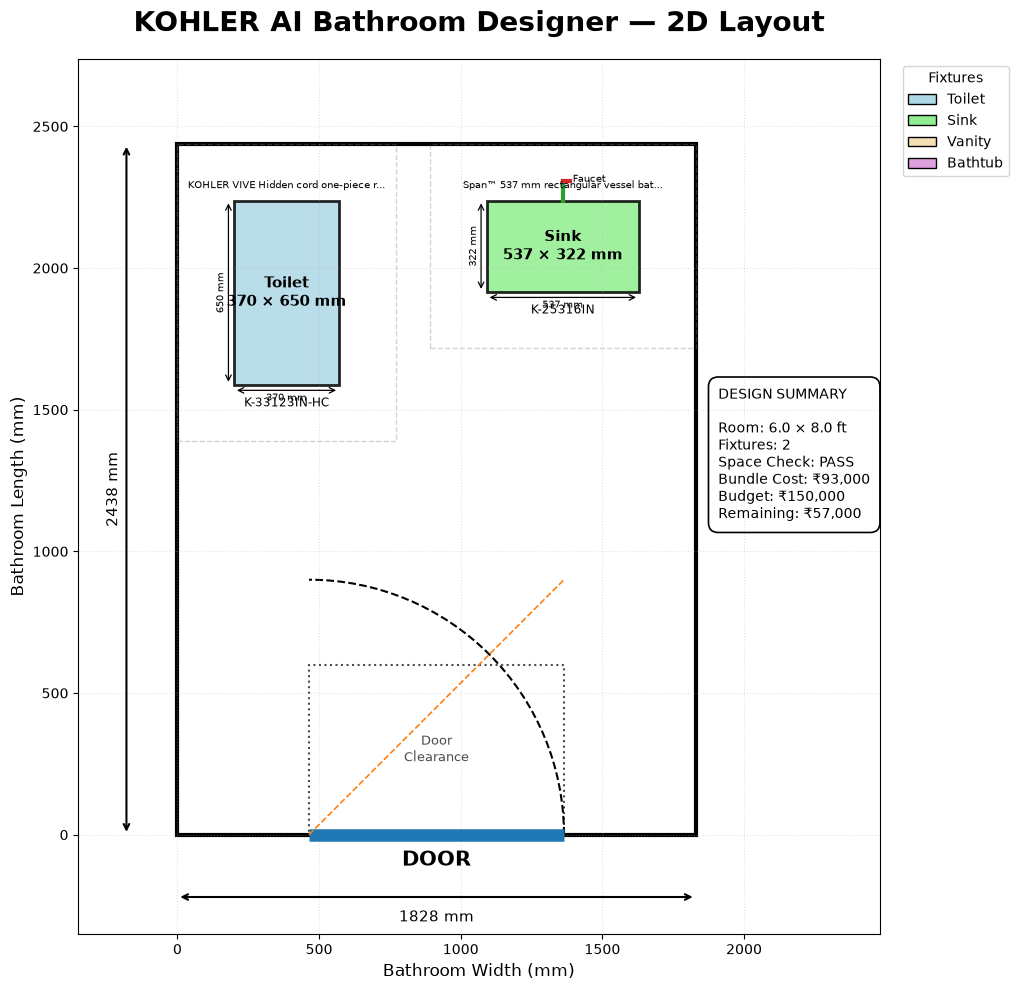

In [108]:
# Cell 55 — Display Selected Bathroom Layout

if (
    "selected_layout" in globals()
    and selected_layout is not None
):

    layout_figure = plot_bathroom_layout(
        selected_layout,

        ROOM_LENGTH_MM,

        ROOM_WIDTH_MM,

        DOOR_WIDTH_MM,
    )

    if layout_figure is not None:

        plt.show()

else:

    print(
        "No selected layout available."
    )

In [109]:
# Cell 56 — Save Bathroom Layout Image

LAYOUT_IMAGE_PATH = (
    "kohler_selected_bathroom_layout.png"
)


if (
    "selected_layout" in globals()
    and selected_layout is not None
    and selected_layout["status"] == "PASS"
):

    fig = plot_bathroom_layout(
        selected_layout,

        ROOM_LENGTH_MM,

        ROOM_WIDTH_MM,

        DOOR_WIDTH_MM,
    )


    if fig is not None:

        fig.savefig(
            LAYOUT_IMAGE_PATH,

            dpi=200,

            bbox_inches="tight",
        )

        plt.close(fig)


        print(
            "Layout image saved successfully."
        )

        print(
            "Path:",
            LAYOUT_IMAGE_PATH
        )

else:

    print(
        "No valid layout available to save."
    )

Layout image saved successfully.
Path: kohler_selected_bathroom_layout.png
